<a href="https://colab.research.google.com/github/erralorenzo/Courses-Kag/blob/main/Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Kaggle Course: Computer Vision**

This notebook is a comprehensive guide to Computer Vision with Keras, structured into six modules that transition from theoretical basics to practical model optimization:

*   **The Convolutional Classifier:** Learn how to build an image classifier by attaching a custom head to a pretrained base (like VGG16).
*   **Convolution and ReLU:** Discover how convolutional layers extract features using kernels and how ReLU activation detects them.
*   **Maximum Pooling:** Explore how to condense feature maps to reduce dimensionality and increase the intensity of extracted features.
*   **The Sliding Window:** Understand the parameters of stride and padding that control how filters move across an image.
*   **Custom Convnets:** Design and build your own architectures by combining convolutional and pooling blocks.
*   **Data Augmentation:** Boost performance by creating synthetic training data through random transformations.

### **Credits & Resources**

The following resources from Kaggle Learn are the primary sources for this content:

*   **Course Home:** [Kaggle Computer Vision](https://www.kaggle.com/learn/computer-vision)

**Curso de Visión por Computadora en Kaggle**

Este cuaderno es una guía completa para la Visión por Computadora con Keras, estructurado en seis módulos que van desde los fundamentos teóricos hasta la optimización práctica de modelos:

*   **El Clasificador Convolucional:** Introduce la construcción de tu primer modelo de visión utilizando una base preentrenada (como VGG16) y una cabeza personalizada para clasificación binaria.
*   **Convolución y ReLU:** Explora cómo las capas convolucionales extraen características mediante filtros (kernels) y cómo la función ReLU las detecta resaltando la información relevante.
*   **Maximum Pooling:** Aprende a condensar los mapas de características para reducir la dimensionalidad y aumentar la intensidad de las características extraídas.
*   **La Ventana Deslizante:** Examina los parámetros de 'stride' y 'padding' que controlan cómo los filtros se desplazan a través de la imagen y cómo afectan al tamaño de salida.
*   **Redes Convolucionales Personalizadas (Custom Convnets):** Diseño y construcción de arquitecturas propias mediante la combinación de bloques de convolución y pooling.
*   **Aumento de Datos (Data Augmentation):** Mejora el rendimiento del modelo creando datos sintéticos mediante transformaciones aleatorias para mejorar la generalización.

### Créditos y Recursos

Los siguientes recursos de Kaggle Learn son las fuentes principales para este contenido:

*   **Inicio del Curso:** [Kaggle Computer Vision](https://www.kaggle.com/learn/computer-vision)

# 1 The Convolutional Classifier
Create your first computer vision model with Keras.




In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ryanholbrook_cv_course_models_path = kagglehub.dataset_download('ryanholbrook/cv-course-models')
ryanholbrook_computer_vision_resources_path = kagglehub.dataset_download('ryanholbrook/computer-vision-resources')
ryanholbrook_car_or_truck_path = kagglehub.dataset_download('ryanholbrook/car-or-truck')

print('Data source import complete.')


## Welcome to Computer Vision! #

Have you ever wanted to teach a computer to see? In this course, that's exactly what you'll do!

In this course, you'll:
- Use modern deep-learning networks to build an **image classifier** with Keras
- Design your own **custom convnet** with reusable blocks
- Learn the fundamental ideas behind visual **feature extraction**
- Master the art of **transfer learning** to boost your models
- Utilize **data augmentation** to extend your dataset

If you've taken the *Introduction to Deep Learning* course, you'll know everything you need to be successful.

Now let's get started!

## Introduction #

This course will introduce you to the fundamental ideas of computer vision. Our goal is to learn how a neural network can "understand" a natural image well-enough to solve the same kinds of problems the human visual system can solve.

The neural networks that are best at this task are called **convolutional neural networks** (Sometimes we say **convnet** or **CNN** instead.) Convolution is the mathematical operation that gives the layers of a convnet their unique structure. In future lessons, you'll learn why this structure is so effective at solving computer vision problems.

We will apply these ideas to the problem of **image classification**: given a picture, can we train a computer to tell us what it's a picture *of*? You may have seen [apps](https://identify.plantnet.org/) that can identify a species of plant from a photograph. That's an image classifier! In this course, you'll learn how to build image classifiers just as powerful as those used in professional applications.

While our focus will be on image classification, what you'll learn in this course is relevant to every kind of computer vision problem. At the end, you'll be ready to move on to more advanced applications like generative adversarial networks and image segmentation.

## The Convolutional Classifier #

A convnet used for image classification consists of two parts: a **convolutional base** and a **dense head**.

<center>
<!-- <img src="./images/1-parts-of-a-convnet.png" width="600" alt="The parts of a convnet: image, base, head, class; input, extract, classify, output.">-->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/U0n5xjU.png" width="600" alt="The parts of a convnet: image, base, head, class; input, extract, classify, output.">
</center>

The base is used to **extract the features** from an image. It is formed primarily of layers performing the convolution operation, but often includes other kinds of layers as well. (You'll learn about these in the next lesson.)

The head is used to **determine the class** of the image. It is formed primarily of dense layers, but might include other layers like dropout.

What do we mean by visual feature? A feature could be a line, a color, a texture, a shape, a pattern -- or some complicated combination.

The whole process goes something like this:

<center>
<!-- <img src="./images/1-extract-classify.png" width="600" alt="The idea of feature extraction."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/UUAafkn.png" width="600" alt="The idea of feature extraction.">
</center>

The features actually extracted look a bit different, but it gives the idea.

## Training the Classifier #

The goal of the network during training is to learn two things:
1. which features to extract from an image (base),
2. which class goes with what features (head).

These days, convnets are rarely trained from scratch. More often, we **reuse the base of a pretrained model**. To the pretrained base we then **attach an untrained head**. In other words, we reuse the part of a network that has already learned to do *1. Extract features*, and attach to it some fresh layers to learn *2. Classify*.

<center>
<!-- <img src="./images/1-attach-head-to-base.png" width="400" alt="Attaching a new head to a trained base."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/E49fsmV.png" width="400" alt="Attaching a new head to a trained base.">
</center>

Because the head usually consists of only a few dense layers, very accurate classifiers can be created from relatively little data.

Reusing a pretrained model is a technique known as **transfer learning**. It is so effective, that almost every image classifier these days will make use of it.

## Example - Train a Convnet Classifier #

Throughout this course, we're going to be creating classifiers that attempt to solve the following problem: is this a picture of a *Car* or of a *Truck*? Our dataset is about 10,000 pictures of various automobiles, around half cars and half trucks.

### Step 1 - Load Data ##

This next hidden cell will import some libraries and set up our data pipeline. We have a training split called `ds_train` and a validation split called `ds_valid`.

In [ ]:

# Imports
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Reproducability
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed(31415)

# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells


# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    '../input/car-or-truck/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
)
ds_valid_ = image_dataset_from_directory(
    '../input/car-or-truck/valid',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


Let's take a look at a few examples from the training set.

In [ ]:

import matplotlib.pyplot as plt

### Step 2 - Define Pretrained Base ##

The most commonly used dataset for pretraining is [*ImageNet*](http://image-net.org/about-overview), a large dataset of many kind of natural images. Keras includes a variety models pretrained on ImageNet in its [`applications` module](https://www.tensorflow.org/api_docs/python/tf/keras/applications). The pretrained model we'll use is called **VGG16**.

In [ ]:
pretrained_base = tf.keras.models.load_model(
    '../input/cv-course-models/cv-course-models/vgg16-pretrained-base',
)
pretrained_base.trainable = False

### Step 3 - Attach Head ##

Next, we attach the classifier head. For this example, we'll use a layer of hidden units (the first `Dense` layer) followed by a layer to transform the outputs to a probability score for class 1, `Truck`. The `Flatten` layer transforms the two dimensional outputs of the base into the one dimensional inputs needed by the head.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    pretrained_base,
    layers.Flatten(),
    layers.Dense(6, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

### Step 4 - Train ##

Finally, let's train the model. Since this is a two-class problem, we'll use the binary versions of `crossentropy` and `accuracy`. The `adam` optimizer generally performs well, so we'll choose it as well.

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=30,
    verbose=0,
)

When training a neural network, it's always a good idea to examine the loss and metric plots. The `history` object contains this information in a dictionary `history.history`. We can use Pandas to convert this dictionary to a dataframe and plot it with a built-in method.

In [ ]:
import pandas as pd

history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

## Conclusion #

In this lesson, we learned about the structure of a convnet classifier: a **head** to act as a classifier atop of a **base** which performs the feature extraction.

The head, essentially, is an ordinary classifier like you learned about in the introductory course. For features, it uses those features extracted by the base. This is the basic idea behind convolutional classifiers: that we can attach a unit that performs feature engineering to the classifier itself.

This is one of the big advantages deep neural networks have over traditional machine learning models: given the right network structure, the deep neural net can learn how to engineer the features it needs to solve its problem.

For the next few lessons, we'll take a look at how the convolutional base accomplishes the feature extraction. Then, you'll learn how to apply these ideas and design some classifiers of your own.

# Exercise 1 The Convolutional Classifier


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ryanholbrook_cv_course_models_path = kagglehub.dataset_download('ryanholbrook/cv-course-models')
ryanholbrook_computer_vision_resources_path = kagglehub.dataset_download('ryanholbrook/computer-vision-resources')
ryanholbrook_car_or_truck_path = kagglehub.dataset_download('ryanholbrook/car-or-truck')

print('Data source import complete.')


## Introduction #

In the tutorial, we saw how to build an image classifier by attaching a head of dense layers to a pretrained base. The base we used was from a model called **VGG16**. We saw that the VGG16 architecture was prone to overfitting this dataset. Over this course, you'll learn a number of ways you can improve upon this initial attempt.

The first way you'll see is to use a base more appropriate to the dataset. The base this model comes from is called **InceptionV1** (also known as GoogLeNet). InceptionV1 was one of the early winners of the ImageNet competition. One of its successors, InceptionV4, is among the state of the art today.

To get started, run the code cell below to set everything up.

In [ ]:
# Setup feedback system
from learntools.core import binder
binder.bind(globals())
from learntools.computer_vision.ex1 import *

# Imports
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Reproducability
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed()

# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells


# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    '../input/car-or-truck/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
)
ds_valid_ = image_dataset_from_directory(
    '../input/car-or-truck/valid',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


2026-07-21 15:50:04.190621: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-21 15:50:04.190785: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-21 15:50:04.345526: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 5117 files belonging to 2 classes.
Found 5051 files belonging to 2 classes.


The **InceptionV1** model pretrained on ImageNet is available in the [TensorFlow Hub](https://www.tensorflow.org/hub/) repository, but we'll load it from a local copy. Run this cell to load InceptionV1 for your base.

In [ ]:
import tensorflow_hub as hub

pretrained_base = tf.keras.models.load_model(
    '../input/cv-course-models/cv-course-models/inceptionv1'
)

## 1) Define Pretrained Base #

Now that you have a pretrained base to do our feature extraction, decide whether this base should be trainable or not.

In [ ]:
# YOUR_CODE_HERE
pretrained_base.trainable = False

# Check your answer
q_1.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> When doing transfer learning, it's generally not a good idea to retrain the entire base -- at least not without some care. The reason is that the random weights in the head will initially create large gradient updates, which propogate back into the base layers and destroy much of the pretraining. Using techniques known as **fine tuning** it's possible to further train the base on new data, but this requires some care to do well.

When doing transfer learning, it's generally not a good idea to retrain the entire base -- at least not without some care. The reason is that the random weights in the head will initially create large gradient updates, which propogate back into the base layers and destroy much of the pretraining. Using techniques known as fine tuning it's possible to further train the base on new data, but this requires some care to do well.

In [ ]:
# Lines below will give you a hint or solution code
#q_1.hint()
#q_1.solution()

## 2) Attach Head #

Now that the base is defined to do the feature extraction, create a head of `Dense` layers to perform the classification, following this diagram:

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/i5VU7Ry.png" alt="Diagram of the dense head.">
</figure>


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    pretrained_base,
    layers.Flatten(),
    layers.Dense(6, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Check your answer
q_2.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#q_2.hint()
#q_2.solution()

## 3) Train #

Before training a model in Keras, you need to specify an *optimizer* to perform the gradient descent, a *loss function* to be minimized, and (optionally) any *performance metrics*. The optimization algorithm we'll use for this course is called ["Adam"](https://keras.io/api/optimizers/adam/), which generally performs well regardless of what kind of problem you're trying to solve.

The loss and the metrics, however, need to match the kind of problem you're trying to solve. Our problem is a **binary classification** problem: `Car` coded as 0, and `Truck` coded as 1. Choose an appropriate loss and an appropriate accuracy metric for binary classification.

In [ ]:
# YOUR CODE HERE: what loss function should you use for a binary
# classification problem? (Your answer for each should be a string.)
optimizer = tf.keras.optimizers.Adam(epsilon=0.01)
model.compile(
    optimizer=optimizer,
    loss = 'binary_crossentropy',
    metrics=['binary_accuracy'],
)

# Check your answer
q_3.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#q_3.hint()
#q_3.solution()

In [ ]:
history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=30,
)

Epoch 1/30
80/80 [==============================] - 145s 2s/step - loss: 0.5669 - binary_accuracy: 0.7002 - val_loss: 0.4346 - val_binary_accuracy: 0.8089
Epoch 2/30
80/80 [==============================] - 104s 1s/step - loss: 0.4152 - binary_accuracy: 0.8136 - val_loss: 0.3973 - val_binary_accuracy: 0.8252
Epoch 3/30
80/80 [==============================] - 106s 1s/step - loss: 0.3859 - binary_accuracy: 0.8253 - val_loss: 0.3835 - val_binary_accuracy: 0.8331
Epoch 4/30
80/80 [==============================] - 110s 1s/step - loss: 0.3694 - binary_accuracy: 0.8392 - val_loss: 0.3753 - val_binary_accuracy: 0.8361
Epoch 5/30
80/80 [==============================] - 105s 1s/step - loss: 0.3574 - binary_accuracy: 0.8450 - val_loss: 0.3696 - val_binary_accuracy: 0.8400
Epoch 6/30
80/80 [==============================] - 105s 1s/step - loss: 0.3474 - binary_accuracy: 0.8511 - val_loss: 0.3654 - val_binary_accuracy: 0.8424
Epoch 7/30
80/80 [==============================] - 105s 1s/step - los

Run the cell below to plot the loss and metric curves for this training run.

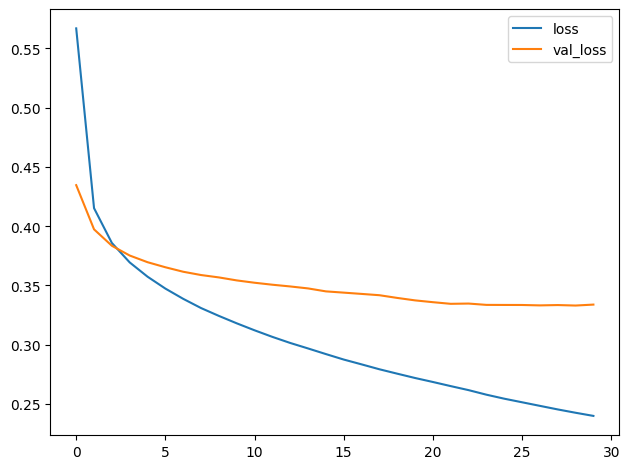

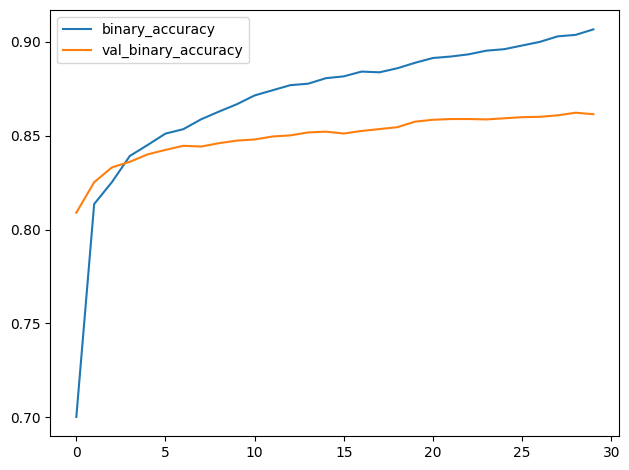

In [ ]:
import pandas as pd
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

## 4) Examine Loss and Accuracy #

Do you notice a difference between these learning curves and the curves for VGG16 from the tutorial? What does this difference tell you about what this model (InceptionV2) learned compared to VGG16? Are there ways in which one is better than the other? Worse?

After you've thought about it, run the cell below to see the answer.

In [ ]:
# View the solution (Run this code cell to receive credit!)
q_4.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

That the training loss and validation loss stay fairly close is evidence that the model isn't just memorizing the training data, but rather learning general properties of the two classes. But, because this model converges at a loss greater than the VGG16 model, it's likely that it is underfitting some, and could benefit from some extra capacity.


## Conclusion #

In this first lesson, you learned the basics of **convolutional image classifiers**, that they consist of a **base** for extracting features from images, and a **head** which uses the features to decide the image's class. You also saw how to build a classifier with **transfer learning** on pretrained base.


# 2 Convolution and ReLU
Discover how convnets create features with convolutional layers.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ryanholbrook_cv_course_models_path = kagglehub.dataset_download('ryanholbrook/cv-course-models')
ryanholbrook_computer_vision_resources_path = kagglehub.dataset_download('ryanholbrook/computer-vision-resources')
ryanholbrook_car_or_truck_path = kagglehub.dataset_download('ryanholbrook/car-or-truck')

print('Data source import complete.')


<!--TITLE: Convolution and ReLU-->

In [ ]:

import numpy as np
from itertools import product

def show_kernel(kernel, label=True, digits=None, text_size=28):
    # Format kernel
    kernel = np.array(kernel)
    if digits is not None:
        kernel = kernel.round(digits)

    # Plot kernel
    cmap = plt.get_cmap('Blues_r')
    plt.imshow(kernel, cmap=cmap)
    rows, cols = kernel.shape
    thresh = (kernel.max()+kernel.min())/2
    # Optionally, add value labels
    if label:
        for i, j in product(range(rows), range(cols)):
            val = kernel[i, j]
            color = cmap(0) if val > thresh else cmap(255)
            plt.text(j, i, val,
                     color=color, size=text_size,
                     horizontalalignment='center', verticalalignment='center')
    plt.xticks([])
    plt.yticks([])

## Introduction #

In the last lesson, we saw that a convolutional classifier has two parts: a convolutional **base** and a **head** of dense layers. We learned that the job of the base is to extract visual features from an image, which the head would then use to classify the image.

Over the next few lessons, we're going to learn about the two most important types of layers that you'll usually find in the base of a convolutional image classifier. These are the **convolutional layer** with **ReLU activation**, and the **maximum pooling layer**. In Lesson 5, you'll learn how to design your own convnet by composing these layers into blocks that perform the feature extraction.

This lesson is about the convolutional layer with its ReLU activation function.

# Feature Extraction #

Before we get into the details of convolution, let's discuss the *purpose* of these layers in the network. We're going to see how these three operations (convolution, ReLU, and maximum pooling) are used to implement the feature extraction process.

The **feature extraction** performed by the base consists of **three basic operations**:
1. **Filter** an image for a particular feature (convolution)
2. **Detect** that feature within the filtered image (ReLU)
3. **Condense** the image to enhance the features (maximum pooling)

The next figure illustrates this process. You can see how these three operations are able to isolate some particular characteristic of the original image (in this case, horizontal lines).

<figure>
<!-- <img src="./images/2-show-extraction.png" width="1200" alt="An example of the feature extraction process."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/IYO9lqp.png" width="600" alt="An example of the feature extraction process.">
<figcaption style="textalign: center; font-style: italic"><center>The three steps of feature extraction.</center></figcaption>
</figure>

Typically, the network will perform several extractions in parallel on a single image. In modern convnets, it's not uncommon for the final layer in the base to be producing over 1000 unique visual features.

# Filter with Convolution #

A convolutional layer carries out the filtering step. You might define a convolutional layer in a Keras model something like this:

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=64, kernel_size=3), # activation is None
    # More layers follow
])

We can understand these parameters by looking at their relationship to the *weights* and *activations* of the layer. Let's do that now.

### Weights ##

The **weights** a convnet learns during training are primarily contained in its convolutional layers. These weights we call **kernels**. We can represent them as small arrays:

<figure>
<!-- <img src="./images/3-kernel.png" width="150" alt="A 3x3 kernel."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/uJfD9r9.png" width="150" alt="A 3x3 kernel.">
</figure>

A kernel operates by scanning over an image and producing a *weighted sum* of pixel values. In this way, a kernel will act sort of like a polarized lens, emphasizing or deemphasizing certain patterns of information.

<figure>
<!-- <img src="./images/3-kernel-lens.png" width="400" alt="A kernel acts as a kind of lens."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/j3lk26U.png" width="250" alt="A kernel acts as a kind of lens.">
<figcaption style="textalign: center; font-style: italic"><center>A kernel acts as a kind of lens.</center></figcaption>
</figure>

Kernels define how a convolutional layer is connected to the layer that follows. The kernel above will connect each neuron in the output to nine neurons in the input. By setting the dimensions of the kernels with `kernel_size`, you are telling the convnet how to form these connections. Most often, a kernel will have odd-numbered dimensions -- like `kernel_size=(3, 3)` or `(5, 5)` -- so that a single pixel sits at the center, but this is not a requirement.

The kernels in a convolutional layer determine what kinds of features it creates. During training, a convnet tries to learn what features it needs to solve the classification problem. This means finding the best values for its kernels.

<!--TODO: Learning a kernel-->

## Activations ##

The **activations** in the network we call **feature maps**. They are what result when we apply a filter to an image; they contain the visual features the kernel extracts. Here are a few kernels pictured with feature maps they produced.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/JxBwchH.png" width="800" alt="Three kernels and the feature maps they produce."><figcaption style="textalign: center; font-style: italic"><center>Kernels and features.</center></figcaption>
</figure>

From the pattern of numbers in the kernel, you can tell the kinds of feature maps it creates. Generally, what a convolution accentuates in its inputs will match the shape of the *positive* numbers in the kernel. The left and middle kernels above will both filter for horizontal shapes.

With the `filters` parameter, you tell the convolutional layer how many feature maps you want it to create as output.

# Detect with ReLU #

After filtering, the feature maps pass through the activation function. The **rectifier function** has a graph like this:

<figure>
<!-- <img src="./images/relu.png" width="300" alt=""> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/DxGJuTH.png" width="300" alt="Graph of the ReLU activation function.">
<figcaption style="textalign: center; font-style: italic"><center>The graph of the rectifier function looks like a line with the negative part "rectified" to 0.</center></figcaption>
</figure>

A neuron with a rectifier attached is called a *rectified linear unit*. For that reason, we might also call the rectifier function the **ReLU activation** or even the ReLU function.

The ReLU activation can be defined in its own `Activation` layer, but most often you'll just include it as the activation function of `Conv2D`.

In [ ]:
model = keras.Sequential([
    layers.Conv2D(filters=64, kernel_size=3, activation='relu')
    # More layers follow
])

You could think about the activation function as scoring pixel values according to some measure of importance. The ReLU activation says that negative values are not important and so sets them to 0. ("Everything unimportant is equally unimportant.")

Here is ReLU applied the feature maps above. Notice how it succeeds at isolating the features.

<figure>
<!-- <img src="./images/3-relu-and-maps.png" width="800" alt="ReLU applied to feature maps."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/dKtwzPY.png" width="800" alt="ReLU applied to feature maps.">
</figure>

Like other activation functions, the ReLU function is **nonlinear**. Essentially this means that the total effect of all the layers in the network becomes different than what you would get by just adding the effects together -- which would be the same as what you could achieve with only a single layer. The nonlinearity ensures features will combine in interesting ways as they move deeper into the network. (We'll explore this "feature compounding" more in Lesson 5.)

## Example - Apply Convolution and ReLU #

We'll do the extraction ourselves in this example to understand better what convolutional networks are doing "behind the scenes".

Here is the image we'll use for this example:

In [ ]:

import tensorflow as tf
import matplotlib.pyplot as plt
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

image_path = '../input/computer-vision-resources/car_feature.jpg'
image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image), cmap='gray')
plt.axis('off')
plt.show();

For the filtering step, we'll define a kernel and then apply it with the convolution. The kernel in this case is an "edge detection" kernel. You can define it with `tf.constant` just like you'd define an array in Numpy with `np.array`. This creates a *tensor* of the sort TensorFlow uses.

In [ ]:
import tensorflow as tf

kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
])

plt.figure(figsize=(3, 3))
show_kernel(kernel)

TensorFlow includes many common operations performed by neural networks in its `tf.nn` [module](https://www.tensorflow.org/api_docs/python/tf/nn). The two that we'll use are `conv2d` and `relu`. These are simply function versions of Keras layers.

This next hidden cell does some reformatting to make things compatible with TensorFlow. The details aren't important for this example.

In [ ]:

# Reformat for batch compatibility.
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
kernel = tf.cast(kernel, dtype=tf.float32)

Now let's apply our kernel and see what happens.

In [ ]:
image_filter = tf.nn.conv2d(
    input=image,
    filters=kernel,
    # we'll talk about these two in lesson 4!
    strides=1,
    padding='SAME',
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.show();

Next is the detection step with the ReLU function. This function is much simpler than the convolution, as it doesn't have any parameters to set.

In [ ]:
image_detect = tf.nn.relu(image_filter)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.show();

And now we've created a feature map! Images like these are what the head uses to solve its classification problem. We can imagine that certain features might be more characteristic of *Cars* and others more characteristic of *Trucks*. The task of a convnet during training is to create kernels that can find those features.

## Conclusion #

We saw in this lesson the first two steps a convnet uses to perform feature extraction: **filter** with `Conv2D` layers and **detect** with `relu` activation.


# Exercise 2 Convolution and ReLU


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ryanholbrook_cv_course_models_path = kagglehub.dataset_download('ryanholbrook/cv-course-models')
ryanholbrook_computer_vision_resources_path = kagglehub.dataset_download('ryanholbrook/computer-vision-resources')
ryanholbrook_car_or_truck_path = kagglehub.dataset_download('ryanholbrook/car-or-truck')

print('Data source import complete.')


**This notebook is an exercise in the [Computer Vision](https://www.kaggle.com/learn/computer-vision) course.  You can reference the tutorial at [this link](https://www.kaggle.com/ryanholbrook/convolution-and-relu).**

---


## Introduction #

In this exercise, you'll work on building some intuition around feature extraction. First, we'll walk through the example we did in the tutorial again, but this time, with a kernel you choose yourself. We've mostly been working with images in this course, but what's behind all of the operations we're learning about is mathematics. So, we'll also take a look at how these feature maps can be represented instead as arrays of numbers and what effect convolution with a kernel will have on them.

Run the cell below to get started!

In [ ]:
# Setup feedback system
from learntools.core import binder
binder.bind(globals())
from learntools.computer_vision.ex2 import *

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

tf.config.run_functions_eagerly(True)

2026-07-21 18:06:55.547410: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-21 18:06:55.547545: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-21 18:06:55.679711: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Apply Transformations #

The next few exercises walk through feature extraction just like the example in the tutorial. Run the following cell to load an image we'll use for the next few exercises.

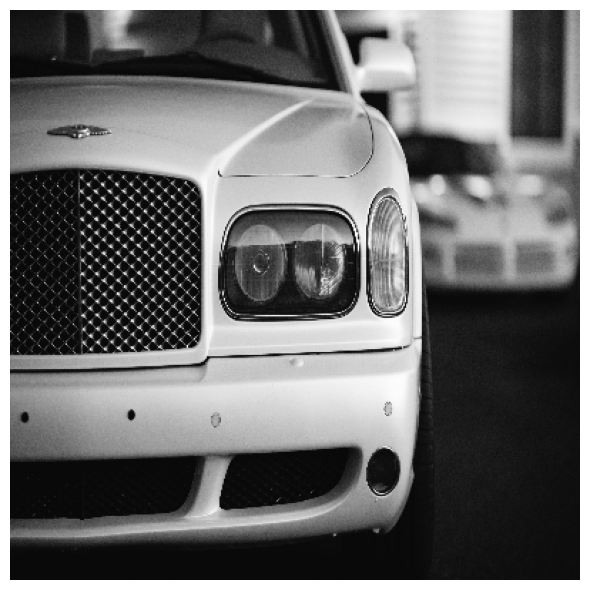

In [ ]:
image_path = '../input/computer-vision-resources/car_illus.jpg'
image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, size=[400, 400])

img = tf.squeeze(image).numpy()
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show();

You can run this cell to see some standard kernels used in image processing.

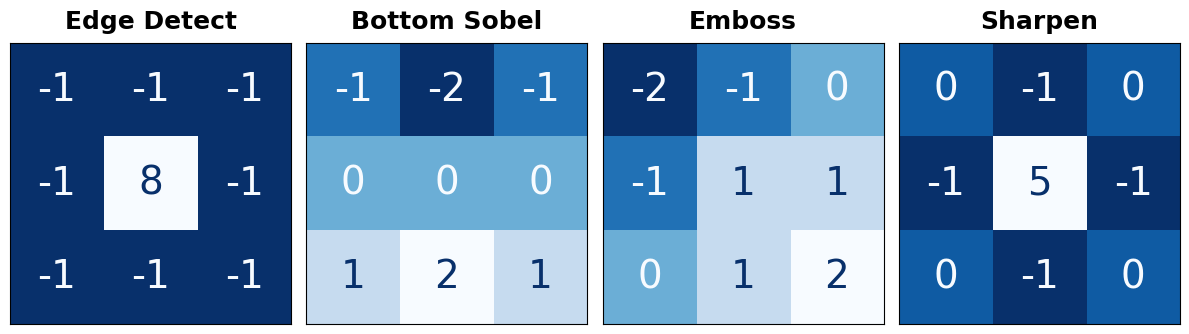

In [ ]:
import learntools.computer_vision.visiontools as visiontools
from learntools.computer_vision.visiontools import edge, bottom_sobel, emboss, sharpen

kernels = [edge, bottom_sobel, emboss, sharpen]
names = ["Edge Detect", "Bottom Sobel", "Emboss", "Sharpen"]

plt.figure(figsize=(12, 12))
for i, (kernel, name) in enumerate(zip(kernels, names)):
    plt.subplot(1, 4, i+1)
    visiontools.show_kernel(kernel)
    plt.title(name)
plt.tight_layout()

## 1) Define Kernel #

Use the next code cell to define a kernel. You have your choice of what kind of kernel to apply. One thing to keep in mind is that the *sum* of the numbers in the kernel determines how bright the final image is. Generally, you should try to keep the sum of the numbers between 0 and 1 (though that's not required for a correct answer).

In general, a kernel can have any number of rows and columns. For this exercise, let's use a $3 \times 3$ kernel, which often gives the best results. Define a kernel with `tf.constant`.

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

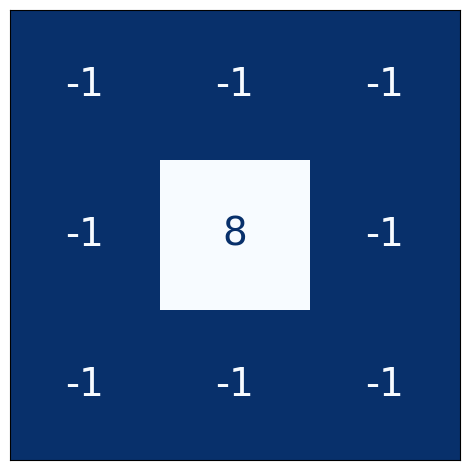

In [ ]:
# YOUR CODE HERE: Define a kernel with 3 rows and 3 columns.
kernel = tf.constant([
     [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
])
# Uncomment to view kernel
visiontools.show_kernel(kernel)

# Check your answer
q_1.check()

In [ ]:
# Lines below will give you a hint or solution code
#q_1.hint()
#q_1.solution()

Now we'll do the first step of feature extraction, the filtering step. First run this cell to do some reformatting for TensorFlow.

In [ ]:
# Reformat for batch compatibility.
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
kernel = tf.cast(kernel, dtype=tf.float32)

## 2) Apply Convolution #

Now we'll apply the kernel to the image by a convolution. The *layer* in Keras that does this is `layers.Conv2D`. What is the *backend function* in TensorFlow that performs the same operation?

In [ ]:
# YOUR CODE HERE: Give the TensorFlow convolution function (without arguments)
conv_fn = tf.nn.conv2d

# Check your answer
q_2.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
# q_2.hint()
# q_2.solution()

Once you've got the correct answer, run this next cell to execute the convolution and see the result!

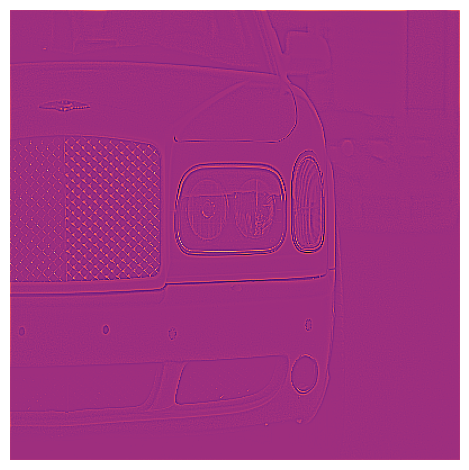

In [ ]:
image_filter = conv_fn(
    input=image,
    filters=kernel,
    strides=1, # or (1, 1)
    padding='SAME',
)

plt.imshow(
    # Reformat for plotting
    tf.squeeze(image_filter)
)
plt.axis('off')
plt.show();

Can you see how the kernel you chose relates to the feature map it produced?

## 3) Apply ReLU #

Now detect the feature with the ReLU function. In Keras, you'll usually use this as the activation function in a `Conv2D` layer. What is the *backend function* in TensorFlow that does the same thing?

In [ ]:
# YOUR CODE HERE: Give the TensorFlow ReLU function (without arguments)
relu_fn = tf.nn.relu

# Check your answer
q_3.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#q_3.hint()
#q_3.solution()

Once you've got the solution, run this cell to detect the feature with ReLU and see the result!

The image you see below is the feature map produced by the kernel you chose. If you like, experiment with some of the other suggested kernels above, or, try to invent one that will extract a certain kind of feature.


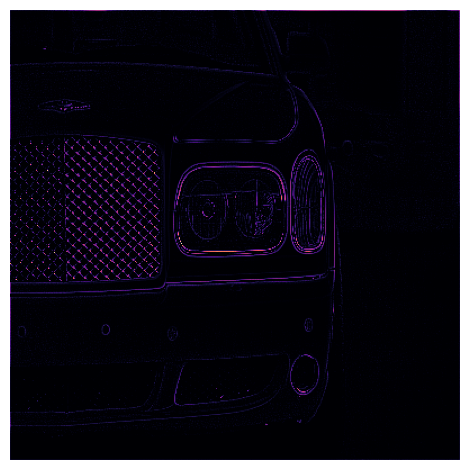

In [ ]:
image_detect = relu_fn(image_filter)

plt.imshow(
    # Reformat for plotting
    tf.squeeze(image_detect)
)
plt.axis('off')
plt.show();

In the tutorial, our discussion of kernels and feature maps was mainly visual. We saw the effect of `Conv2D` and `ReLU` by observing how they transformed some example images.

But the operations in a convolutional network (like in all neural networks) are usually defined through mathematical functions, through a computation on numbers. In the next exercise, we'll take a moment to explore this point of view.

Let's start by defining a simple array to act as an image, and another array to act as the kernel. Run the following cell to see these arrays.

In [ ]:
# Sympy is a python library for symbolic mathematics. It has a nice
# pretty printer for matrices, which is all we'll use it for.
import sympy
sympy.init_printing()
from IPython.display import display

image = np.array([
    [0, 1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0],
    [0, 1, 0, 1, 1, 1],
    [0, 1, 0, 0, 0, 0],
])

kernel = np.array([
    [1, -1],
    [1, -1],
])

display(sympy.Matrix(image))
display(sympy.Matrix(kernel))
# Reformat for Tensorflow
image = tf.cast(image, dtype=tf.float32)
image = tf.reshape(image, [1, *image.shape, 1])
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
kernel = tf.cast(kernel, dtype=tf.float32)

⎡0  1  0  0  0  0⎤
⎢                ⎥
⎢0  1  0  0  0  0⎥
⎢                ⎥
⎢0  1  0  0  0  0⎥
⎢                ⎥
⎢0  1  0  0  0  0⎥
⎢                ⎥
⎢0  1  0  1  1  1⎥
⎢                ⎥
⎣0  1  0  0  0  0⎦

⎡1  -1⎤
⎢     ⎥
⎣1  -1⎦

## 4) Observe Convolution on a Numerical Matrix #


What do you see? The image is simply a long vertical line on the left and a short horizontal line on the lower right. What about the kernel? What effect do you think it will have on this image? After you've thought about it, run the next cell for the answer.

In [ ]:
# View the solution (Run this code cell to receive credit!)
q_4.check()

Now let's try it out. Run the next cell to apply convolution and ReLU to the image and display the result.

In [ ]:
image_filter = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=1,
    padding='VALID',
)
image_detect = tf.nn.relu(image_filter)

# The first matrix is the image after convolution, and the second is
# the image after ReLU.
display(sympy.Matrix(tf.squeeze(image_filter).numpy()))
display(sympy.Matrix(tf.squeeze(image_detect).numpy()))

Is the result what you expected?

## Conclusion #

In this lesson, you learned about the first two operations a convolutional classifier uses for feature extraction: **filtering** an image with a **convolution** and **detecting** the feature with the **rectified linear unit**.


# 3 Maximum Pooling
Learn more about feature extraction with maximum pooling.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ryanholbrook_cv_course_models_path = kagglehub.dataset_download('ryanholbrook/cv-course-models')
ryanholbrook_computer_vision_resources_path = kagglehub.dataset_download('ryanholbrook/computer-vision-resources')
ryanholbrook_car_or_truck_path = kagglehub.dataset_download('ryanholbrook/car-or-truck')

print('Data source import complete.')


<!--TITLE: Maximum Pooling-->
## Introduction #

In Lesson 2 we began our discussion of how the base in a convnet performs feature extraction. We learned about how the first two operations in this process occur in a `Conv2D` layer with `relu` activation.

In this lesson, we'll look at the third (and final) operation in this sequence: **condense** with **maximum pooling**, which in Keras is done by a `MaxPool2D` layer.

# Condense with Maximum Pooling #

Adding condensing step to the model we had before, will give us this:

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=64, kernel_size=3), # activation is None
    layers.MaxPool2D(pool_size=2),
    # More layers follow
])

A `MaxPool2D` layer is much like a `Conv2D` layer, except that it uses a simple maximum function instead of a kernel, with the `pool_size` parameter analogous to `kernel_size`. A `MaxPool2D` layer doesn't have any trainable weights like a convolutional layer does in its kernel, however.

Let's take another look at the extraction figure from the last lesson. Remember that `MaxPool2D` is the **Condense** step.

<figure>
<!-- <img src="./images/2-show-extraction.png" width="1200" alt="An example of the feature extraction process."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/IYO9lqp.png" width="600" alt="An example of the feature extraction process.">
</figure>

Notice that after applying the ReLU function (**Detect**) the feature map ends up with a lot of "dead space," that is, large areas containing only 0's (the black areas in the image). Having to carry these 0 activations through the entire network would increase the size of the model without adding much useful information. Instead, we would like to *condense* the feature map to retain only the most useful part -- the feature itself.

This in fact is what **maximum pooling** does. Max pooling takes a patch of activations in the original feature map and replaces them with the maximum activation in that patch.

<figure>
<!-- <img src="./images/3-max-pooling.png" width="600" alt="Maximum pooling replaces a patch with the maximum value in that patch."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/hK5U2cd.png" width="400" alt="Maximum pooling replaces a patch with the maximum value in that patch.">
</figure>

When applied after the ReLU activation, it has the effect of "intensifying" features. The pooling step increases the proportion of active pixels to zero pixels.

## Example - Apply Maximum Pooling #

Let's add the "condense" step to the feature extraction we did in the example in Lesson 2. This next hidden cell will take us back to where we left off.

In [ ]:

import tensorflow as tf
import matplotlib.pyplot as plt
import warnings

plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells

# Read image
image_path = '../input/computer-vision-resources/car_feature.jpg'
image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image)

# Define kernel
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
], dtype=tf.float32)

# Reformat for batch compatibility.
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])

# Filter step
image_filter = tf.nn.conv2d(
    input=image,
    filters=kernel,
    # we'll talk about these two in the next lesson!
    strides=1,
    padding='SAME'
)

# Detect step
image_detect = tf.nn.relu(image_filter)

# Show what we have so far
plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(tf.squeeze(image), cmap='gray')
plt.axis('off')
plt.title('Input')
plt.subplot(132)
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.title('Filter')
plt.subplot(133)
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.title('Detect')
plt.show();

We'll use another one of the functions in `tf.nn` to apply the pooling step, `tf.nn.pool`. This is a Python function that does the same thing as the `MaxPool2D` layer you use when model building, but, being a simple function, is easier to use directly.

In [ ]:
import tensorflow as tf

image_condense = tf.nn.pool(
    input=image_detect, # image in the Detect step above
    window_shape=(2, 2),
    pooling_type='MAX',
    # we'll see what these do in the next lesson!
    strides=(2, 2),
    padding='SAME',
)

plt.figure(figsize=(6, 6))
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.show();

Pretty cool! Hopefully you can see how the pooling step was able to intensify the feature by condensing the image around the most active pixels.

## Translation Invariance #

We called the zero-pixels "unimportant". Does this mean they carry no information at all? In fact, the zero-pixels carry *positional information*. The blank space still positions the feature within the image. When `MaxPool2D` removes some of these pixels, it removes some of the positional information in the feature map. This gives a convnet a property called **translation invariance**. This means that a convnet with maximum pooling will tend not to distinguish features by their *location* in the image. ("Translation" is the mathematical word for changing the position of something without rotating it or changing its shape or size.)

Watch what happens when we repeatedly apply maximum pooling to the following feature map.

<figure>
<!-- <img src="./images/4-two-dots.png" width="800" alt="Pooling tends to destroy positional information."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/97j8WA1.png" width="800" alt="Pooling tends to destroy positional information.">
</figure>

The two dots in the original image became indistinguishable after repeated pooling. In other words, pooling destroyed some of their positional information. Since the network can no longer distinguish between them in the feature maps, it can't distinguish them in the original image either: it has become *invariant* to that difference in position.

In fact, pooling only creates translation invariance in a network *over small distances*, as with the two dots in the image. Features that begin far apart will remain distinct after pooling; only *some* of the positional information was lost, but not all of it.

<figure>
<!-- <img src="./images/4-two-dots-2.png" width="800" alt="Pooling tends to destroy positional information."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/kUMWdcP.png" width="800" alt="But only over small distances. Two dots far apart stay separated">
</figure>

This invariance to small differences in the positions of features is a nice property for an image classifier to have. Just because of differences in perspective or framing, the same kind of feature might be positioned in various parts of the original image, but we would still like for the classifier to recognize that they are the same. Because this invariance is *built into* the network, we can get away with using much less data for training: we no longer have to teach it to ignore that difference. This gives convolutional networks a big efficiency advantage over a network with only dense layers. (You'll see another way to get invariance for free in **Lesson 6** with **Data Augmentation**!)

# Conclusion #

In this lesson, we learned the about the last step of feature extraction: **condense** with `MaxPool2D`. In Lesson 4, we'll finish up our discussion of convolution and pooling with *sliding windows*.


# 3 Ex Maximum Pooling


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ryanholbrook_cv_course_models_path = kagglehub.dataset_download('ryanholbrook/cv-course-models')
ryanholbrook_computer_vision_resources_path = kagglehub.dataset_download('ryanholbrook/computer-vision-resources')
ryanholbrook_car_or_truck_path = kagglehub.dataset_download('ryanholbrook/car-or-truck')

print('Data source import complete.')


## Introduction #

In these exercises, you'll conclude the feature extraction begun in Exercise 2, explore how invariance is created by maximum pooling, and then look at a different kind of pooling: *average* pooling.

Run the cell below to set everything up.

In [ ]:
# Setup feedback system
from learntools.core import binder
binder.bind(globals())
from learntools.computer_vision.ex3 import *

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib import gridspec
import learntools.computer_vision.visiontools as visiontools

plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

Run this cell to get back to where you left off in the previous lesson. We'll use a predefined kernel this time.

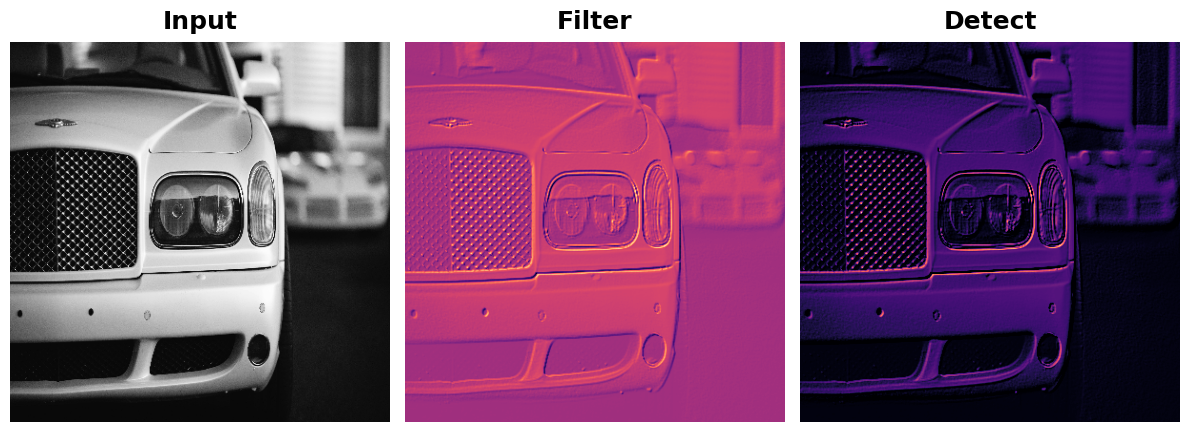

In [ ]:
# Read image
image_path = '../input/computer-vision-resources/car_illus.jpg'
image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, size=[400, 400])

# Embossing kernel
kernel = tf.constant([
    [-2, -1, 0],
    [-1, 1, 1],
    [0, 1, 2],
])

# Reformat for batch compatibility.
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
kernel = tf.cast(kernel, dtype=tf.float32)

image_filter = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=1,
    padding='VALID',
)

image_detect = tf.nn.relu(image_filter)

# Show what we have so far
plt.figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(tf.squeeze(image), cmap='gray')
plt.axis('off')
plt.title('Input')
plt.subplot(132)
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.title('Filter')
plt.subplot(133)
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.title('Detect')
plt.show();

## 1) Apply Pooling to Condense #

For for the last step in the sequence, apply maximum pooling using a $2 \times 2$ pooling window. You can copy this code to get started:

```
image_condense = tf.nn.pool(
    input=image_detect,
    window_shape=____,
    pooling_type=____,
    strides=(2, 2),
    padding='SAME',
)
```

In [ ]:
# YOUR CODE HERE
image_condense = tf.nn.pool(
    input=image_detect,
    window_shape=(2, 2),
    pooling_type='MAX',
    strides=(2, 2),
    padding='SAME',
)
# Check your answer
q_1.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

Run the next cell to see what maximum pooling did to the feature!

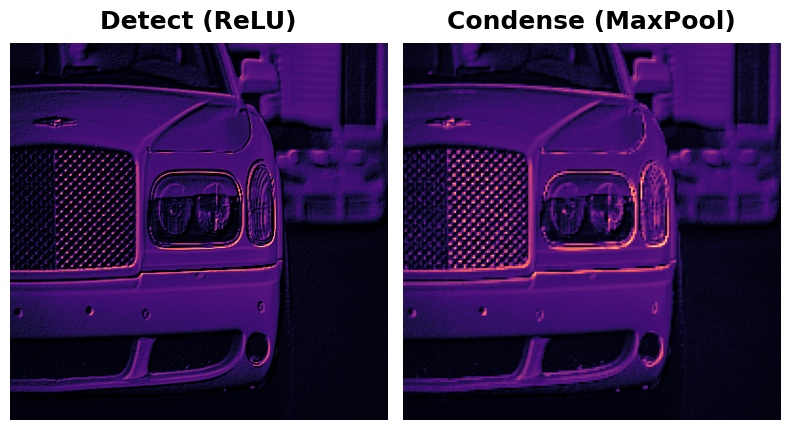

In [ ]:
plt.figure(figsize=(8, 6))
plt.subplot(121)
plt.imshow(tf.squeeze(image_detect))
plt.axis('off')
plt.title("Detect (ReLU)")
plt.subplot(122)
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.title("Condense (MaxPool)")
plt.show();

We learned about how `MaxPool2D` layers give a convolutional network the property of **translation invariance** over small distances. In this exercise, you'll have a chance to observe this in action.

This next code cell will randomly apply a small shift to a circle and then condense the image several times with maximum pooling. Run the cell once and make note of the image that results at the end.

/tmp/__autograph_generated_files8243wnj.py:62: SyntaxWarning: "is" with a literal. Did you mean "=="?
  ag__.if_stmt(ag__.ld(fill_method) is 'reflect', if_body, else_body, get_state, set_state, ('i', 'j'), 2)
/tmp/__autograph_generated_files8243wnj.py:63: SyntaxWarning: "is" with a literal. Did you mean "=="?
  ag__.if_stmt(ag__.ld(fill_method) is 'replicate', if_body_1, else_body_1, get_state_1, set_state_1, ('i', 'j'), 2)


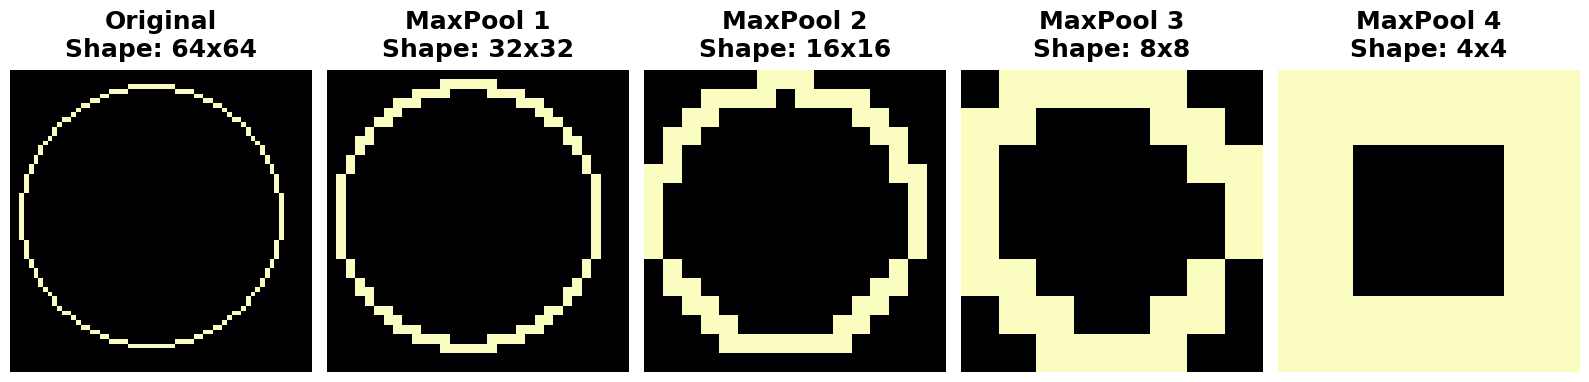

In [ ]:
REPEATS = 4
SIZE = [64, 64]

# Create a randomly shifted circle
image = visiontools.circle(SIZE, r_shrink=4, val=1)
image = tf.expand_dims(image, axis=-1)
image = visiontools.random_transform(image, jitter=3, fill_method='replicate')
image = tf.squeeze(image)

plt.figure(figsize=(16, 4))
plt.subplot(1, REPEATS+1, 1)
plt.imshow(image, vmin=0, vmax=1)
plt.title("Original\nShape: {}x{}".format(image.shape[0], image.shape[1]))
plt.axis('off')

# Now condense with maximum pooling several times
for i in range(REPEATS):
    ax = plt.subplot(1, REPEATS+1, i+2)
    image = tf.reshape(image, [1, *image.shape, 1])
    image = tf.nn.pool(image, window_shape=(2,2), strides=(2, 2), padding='SAME', pooling_type='MAX')
    image = tf.squeeze(image)
    plt.imshow(image, vmin=0, vmax=1)
    plt.title("MaxPool {}\nShape: {}x{}".format(i+1, image.shape[0], image.shape[1]))
    plt.axis('off')

## 2) Explore Invariance #


Suppose you had made a small shift in a different direction -- what effect would you expect that have on the resulting image? Try running the cell a few more times, if you like, to get a new random shift.

In [ ]:
# View the solution (Run this code cell to receive credit!)
q_2.solution()

<IPython.core.display.Javascript object>

<span style="color:#33cc99">Solution:</span> In the tutorial, we talked about how maximum pooling creates **translation invariance** over small distances. This means that we would expect small shifts to disappear after repeated maximum pooling. If you run the cell multiple times, you can see the resulting image is always the same; the pooling operation destroys those small translations.


Solution: In the tutorial, we talked about how maximum pooling creates translation invariance over small distances. This means that we would expect small shifts to disappear after repeated maximum pooling. If you run the cell multiple times, you can see the resulting image is always the same; the pooling operation destroys those small translations.

## Global Average Pooling #

We mentioned in the previous exercise that average pooling has largely been superceeded by maximum pooling within the convolutional base. There is, however, a kind of average pooling that is still widely used in the *head* of a convnet. This is **global average pooling**. A `GlobalAvgPool2D` layer is often used as an alternative to some or all of the hidden `Dense` layers in the head of the network, like so:

```
model = keras.Sequential([
    pretrained_base,
    layers.GlobalAvgPool2D(),
    layers.Dense(1, activation='sigmoid'),
])
```

What is this layer doing? Notice that we no longer have the `Flatten` layer that usually comes after the base to transform the 2D feature data to 1D data needed by the classifier. Now the `GlobalAvgPool2D` layer is serving this function. But, instead of "unstacking" the feature (like `Flatten`), it simply replaces the entire feature map with its average value. Though very destructive, it often works quite well and has the advantage of reducing the number of parameters in the model.

Let's look at what `GlobalAvgPool2D` does on some randomly generated feature maps. This will help us to understand how it can "flatten" the stack of feature maps produced by the base.

Run this next cell a few times until you get a feel for how this new layer works.

/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


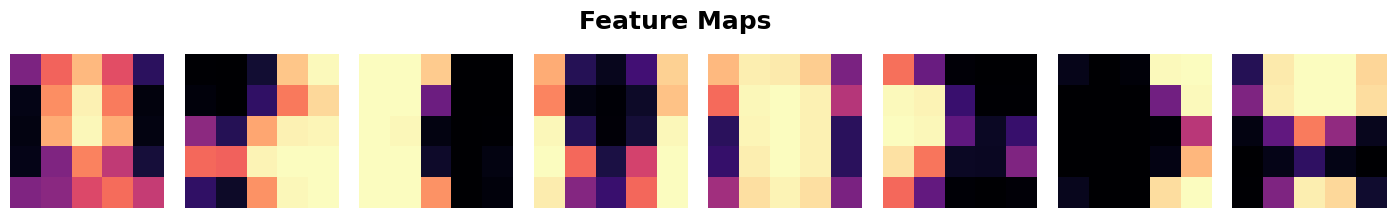

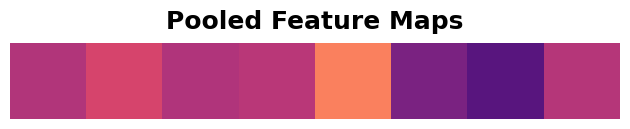

In [ ]:
feature_maps = [visiontools.random_map([5, 5], scale=0.1, decay_power=4) for _ in range(8)]

gs = gridspec.GridSpec(1, 8, wspace=0.01, hspace=0.01)
plt.figure(figsize=(18, 2))
for i, feature_map in enumerate(feature_maps):
    plt.subplot(gs[i])
    plt.imshow(feature_map, vmin=0, vmax=1)
    plt.axis('off')
plt.suptitle('Feature Maps', size=18, weight='bold', y=1.1)
plt.show()

# reformat for TensorFlow
feature_maps_tf = [tf.reshape(feature_map, [1, *feature_map.shape, 1])
                   for feature_map in feature_maps]

global_avg_pool = tf.keras.layers.GlobalAvgPool2D()
pooled_maps = [global_avg_pool(feature_map) for feature_map in feature_maps_tf]
img = np.array(pooled_maps)[:,:,0].T

plt.imshow(img, vmin=0, vmax=1)
plt.axis('off')
plt.title('Pooled Feature Maps')
plt.show();

Since each of the $5 \times 5$ feature maps was reduced to a single value, global pooling reduced the number of parameters needed to represent these features by a factor of 25 -- a substantial savings!

Now we'll move on to understanding the pooled features.

After we've pooled the features into just a single value, does the head still have enough information to determine a class? This part of the exercise will investigate that question.

Let's pass some images from our *Car or Truck* dataset through VGG16 and examine the features that result after pooling. First run this cell to define the model and load the dataset.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Load VGG16
pretrained_base = tf.keras.models.load_model(
    '../input/cv-course-models/cv-course-models/vgg16-pretrained-base',
)

model = keras.Sequential([
    pretrained_base,
    # Attach a global average pooling layer after the base
    layers.GlobalAvgPool2D(),
])

# Load dataset
ds = image_dataset_from_directory(
    '../input/car-or-truck/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=1,
    shuffle=True,
)

ds_iter = iter(ds)

Found 5117 files belonging to 2 classes.


Notice how we've attached a `GlobalAvgPool2D` layer after the pretrained VGG16 base. Ordinarily, VGG16 will produce 512 feature maps for each image. The `GlobalAvgPool2D` layer reduces each of these to a single value, an "average pixel", if you like.

This next cell will run an image from the *Car or Truck* dataset through VGG16 and show you the 512 average pixels created by `GlobalAvgPool2D`. Run the cell a few times and observe the pixels produced by cars versus the pixels produced by trucks.

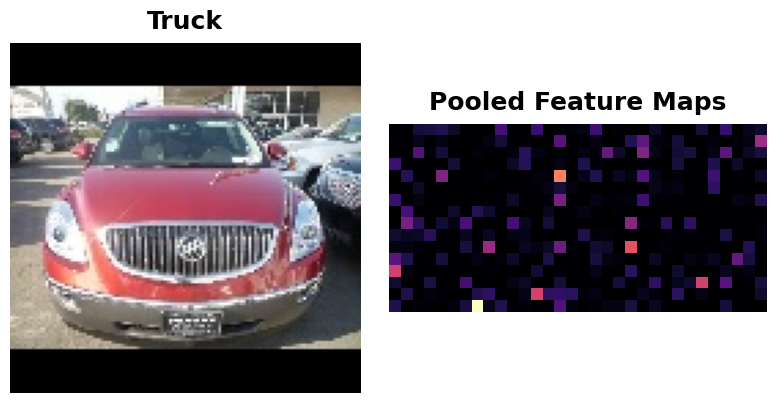

In [ ]:
car = next(ds_iter)

car_tf = tf.image.resize(car[0], size=[128, 128])
car_features = model(car_tf)
car_features = tf.reshape(car_features, shape=(16, 32))
label = int(tf.squeeze(car[1]).numpy())

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(tf.squeeze(car[0]))
plt.axis('off')
plt.title(["Car", "Truck"][label])
plt.subplot(122)
plt.imshow(car_features)
plt.title('Pooled Feature Maps')
plt.axis('off')
plt.show();

## 3) Understand the Pooled Features #

What do you see? Are the pooled features for cars and trucks different enough to tell them apart? How would you interpret these pooled values? How could this help the classification? After you've thought about it, run the next cell for an answer. (Or see a hint first!)

In [ ]:
# View the solution (Run this code cell to receive credit!)
q_3.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

The VGG16 base produces 512 feature maps. We can think of each feature map as representing some high-level visual feature in the original image -- maybe a wheel or window. Pooling a map gives us a single number, which we could think of as a *score* for that feature: large if the feature is present, small if it is absent. Cars tend to score high with one set of features, and Trucks score high with another. Now, instead of trying to map raw features to classes, the head only has to work with these scores that `GlobalAvgPool2D` produced, a much easier problem for it to solve.


The VGG16 base produces 512 feature maps. We can think of each feature map as representing some high-level visual feature in the original image -- maybe a wheel or window. Pooling a map gives us a single number, which we could think of as a score for that feature: large if the feature is present, small if it is absent. Cars tend to score high with one set of features, and Trucks score high with another. Now, instead of trying to map raw features to classes, the head only has to work with these scores that GlobalAvgPool2D produced, a much easier problem for it to solve.

Global average pooling is often used in modern convnets. One big advantage is that it greatly reduces the number of parameters in a model, while still telling you if some feature was present in an image or not -- which for classification is usually all that matters. If you're creating a convolutional classifier it's worth trying out!

## Conclusion #

In this lesson we explored the final operation in the feature extraction process: **condensing** with **maximum pooling**. Pooling is one of the essential features of convolutional networks and helps provide them with some of their characteristic advantages: efficiency with visual data, reduced parameter size compared to dense networks, translation invariance. We've seen that it's used not only in the base during feature extraction, but also can be used in the head during classification. Understanding it is essential to a full understanding of convnets.



# 4 The Sliding Window
Explore two important parameters: stride and padding.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ryanholbrook_cv_course_models_path = kagglehub.dataset_download('ryanholbrook/cv-course-models')
ryanholbrook_computer_vision_resources_path = kagglehub.dataset_download('ryanholbrook/computer-vision-resources')
ryanholbrook_car_or_truck_path = kagglehub.dataset_download('ryanholbrook/car-or-truck')

print('Data source import complete.')


In [ ]:

import numpy as np
from itertools import product
from skimage import draw, transform

def circle(size, val=None, r_shrink=0):
    circle = np.zeros([size[0]+1, size[1]+1])
    rr, cc = draw.circle_perimeter(
        size[0]//2, size[1]//2,
        radius=size[0]//2 - r_shrink,
        shape=[size[0]+1, size[1]+1],
    )
    if val is None:
        circle[rr, cc] = np.random.uniform(size=circle.shape)[rr, cc]
    else:
        circle[rr, cc] = val
    circle = transform.resize(circle, size, order=0)
    return circle

def show_kernel(kernel, label=True, digits=None, text_size=28):
    # Format kernel
    kernel = np.array(kernel)
    if digits is not None:
        kernel = kernel.round(digits)

    # Plot kernel
    cmap = plt.get_cmap('Blues_r')
    plt.imshow(kernel, cmap=cmap)
    rows, cols = kernel.shape
    thresh = (kernel.max()+kernel.min())/2
    # Optionally, add value labels
    if label:
        for i, j in product(range(rows), range(cols)):
            val = kernel[i, j]
            color = cmap(0) if val > thresh else cmap(255)
            plt.text(j, i, val,
                     color=color, size=text_size,
                     horizontalalignment='center', verticalalignment='center')
    plt.xticks([])
    plt.yticks([])

def show_extraction(image,
                    kernel,
                    conv_stride=1,
                    conv_padding='valid',
                    activation='relu',
                    pool_size=2,
                    pool_stride=2,
                    pool_padding='same',
                    figsize=(10, 10),
                    subplot_shape=(2, 2),
                    ops=['Input', 'Filter', 'Detect', 'Condense'],
                    gamma=1.0):
    # Create Layers
    model = tf.keras.Sequential([
                    tf.keras.layers.Conv2D(
                        filters=1,
                        kernel_size=kernel.shape,
                        strides=conv_stride,
                        padding=conv_padding,
                        use_bias=False,
                        input_shape=image.shape,
                    ),
                    tf.keras.layers.Activation(activation),
                    tf.keras.layers.MaxPool2D(
                        pool_size=pool_size,
                        strides=pool_stride,
                        padding=pool_padding,
                    ),
                   ])

    layer_filter, layer_detect, layer_condense = model.layers
    kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
    layer_filter.set_weights([kernel])

    # Format for TF
    image = tf.expand_dims(image, axis=0)
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)

    # Extract Feature
    image_filter = layer_filter(image)
    image_detect = layer_detect(image_filter)
    image_condense = layer_condense(image_detect)

    images = {}
    if 'Input' in ops:
        images.update({'Input': (image, 1.0)})
    if 'Filter' in ops:
        images.update({'Filter': (image_filter, 1.0)})
    if 'Detect' in ops:
        images.update({'Detect': (image_detect, gamma)})
    if 'Condense' in ops:
        images.update({'Condense': (image_condense, gamma)})

    # Plot
    plt.figure(figsize=figsize)
    for i, title in enumerate(ops):
        image, gamma = images[title]
        plt.subplot(*subplot_shape, i+1)
        plt.imshow(tf.image.adjust_gamma(tf.squeeze(image), gamma))
        plt.axis('off')
        plt.title(title)

## Introduction #

In the previous two lessons, we learned about the three operations that carry out feature extraction from an image:
1. *filter* with a **convolution** layer
2. *detect* with **ReLU** activation
3. *condense* with a **maximum pooling** layer

The convolution and pooling operations share a common feature: they are both performed over a **sliding window**. With convolution, this "window" is given by the dimensions of the kernel, the parameter `kernel_size`. With pooling, it is the pooling window, given by `pool_size`.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/LueNK6b.gif" width=400 alt="A 2D sliding window.">
</figure>

There are two additional parameters affecting both convolution and pooling layers -- these are the `strides` of the window and whether to use `padding` at the image edges. The `strides` parameter says how far the window should move at each step, and the `padding` parameter describes how we handle the pixels at the edges of the input.

With these two parameters, defining the two layers becomes:

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=64,
                  kernel_size=3,
                  strides=1,
                  padding='same',
                  activation='relu'),
    layers.MaxPool2D(pool_size=2,
                     strides=1,
                     padding='same')
    # More layers follow
])

## Stride #

The distance the window moves at each step is called the **stride**. We need to specify the stride in both dimensions of the image: one for moving left to right and one for moving top to bottom. This animation shows `strides=(2, 2)`, a movement of 2 pixels each step.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/Tlptsvt.gif" width=400 alt="Sliding window with a stride of (2, 2).">
</figure>

What effect does the stride have? Whenever the stride in either direction is greater than 1, the sliding window will skip over some of the pixels in the input at each step.

Because we want high-quality features to use for classification, convolutional layers will most often have `strides=(1, 1)`. Increasing the stride means that we miss out on potentially valuble information in our summary. Maximum pooling layers, however, will almost always have stride values greater than 1, like `(2, 2)` or `(3, 3)`, but not larger than the window itself.

Finally, note that when the value of the `strides` is the same number in both directions, you only need to set that number; for instance, instead of `strides=(2, 2)`, you could use `strides=2` for the parameter setting.

# Padding #

When performing the sliding window computation, there is a question as to what to do at the boundaries of the input. Staying entirely inside the input image means the window will never sit squarely over these boundary pixels like it does for every other pixel in the input. Since we aren't treating all the pixels exactly the same, could there be a problem?

What the convolution does with these boundary values is determined by its `padding` parameter. In TensorFlow, you have two choices: either `padding='same'` or `padding='valid'`. There are trade-offs with each.

When we set `padding='valid'`, the convolution window will stay entirely inside the input. The drawback is that the output shrinks (loses pixels), and shrinks more for larger kernels. This will limit the number of layers the network can contain, especially when inputs are small in size.

The alternative is to use `padding='same'`. The trick here is to **pad** the input with 0's around its borders, using just enough 0's to make the size of the output the *same* as the size of the input. This can have the effect however of diluting the influence of pixels at the borders. The animation below shows a sliding window with `'same'` padding.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/RvGM2xb.gif" width=400 alt="Illustration of zero (same) padding.">
</figure>

The VGG model we've been looking at uses `same` padding for all of its convolutional layers. Most modern convnets will use some combination of the two. (Another parameter to tune!)

# Example - Exploring Sliding Windows #

To better understand the effect of the sliding window parameters, it can help to observe a feature extraction on a low-resolution image so that we can see the individual pixels. Let's just look at a simple circle.

This next hidden cell will create an image and kernel for us.

In [ ]:

import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

image = circle([64, 64], val=1.0, r_shrink=3)
image = tf.reshape(image, [*image.shape, 1])
# Bottom sobel
kernel = tf.constant(
    [[-1, -2, -1],
     [0, 0, 0],
     [1, 2, 1]],
)

show_kernel(kernel)

The VGG architecture is fairly simple. It uses convolution with strides of 1 and maximum pooling with $2 \times 2$ windows and strides of 2. We've included a function in the `visiontools` utility script that will show us all the steps.

In [ ]:
show_extraction(
    image, kernel,

    # Window parameters
    conv_stride=1,
    pool_size=2,
    pool_stride=2,

    subplot_shape=(1, 4),
    figsize=(14, 6),
)

And that works pretty well! The kernel was designed to detect horizontal lines, and we can see that in the resulting feature map the more horizontal parts of the input end up with the greatest activation.

What would happen if we changed the strides of the convolution to 3?

In [ ]:
show_extraction(
    image, kernel,

    # Window parameters
    conv_stride=3,
    pool_size=2,
    pool_stride=2,

    subplot_shape=(1, 4),
    figsize=(14, 6),
)

This seems to reduce the quality of the feature extracted. Our input circle is rather "finely detailed," being only 1 pixel wide. A convolution with strides of 3 is too coarse to produce a good feature map from it.

Sometimes, a model will use a convolution with a larger stride in it's initial layer. This will usually be coupled with a larger kernel as well. The ResNet50 model, for instance, uses $7 \times 7$ kernels with strides of 2 in its first layer. This seems to accelerate the production of large-scale features without the sacrifice of too much information from the input.

## Conclusion #

In this lesson, we looked at a characteristic computation common to both convolution and pooling: the **sliding window** and the parameters affecting its behavior in these layers. This style of windowed computation contributes much of what is characteristic of convolutional networks and is an essential part of their functioning.



# 4 Ex The Sliding Window
Explore two important parameters: stride and padding.


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ryanholbrook_cv_course_models_path = kagglehub.dataset_download('ryanholbrook/cv-course-models')
ryanholbrook_computer_vision_resources_path = kagglehub.dataset_download('ryanholbrook/computer-vision-resources')
ryanholbrook_car_or_truck_path = kagglehub.dataset_download('ryanholbrook/car-or-truck')

print('Data source import complete.')


## Introduction #

In these exercises, you'll explore the operations a couple of popular convnet architectures use for feature extraction, learn about how convnets can capture large-scale visual features through stacking layers, and finally see how convolution can be used on one-dimensional data, in this case, a time series.

Run the cell below to set everything up.

In [ ]:
# Setup feedback system
from learntools.core import binder
binder.bind(globals())
from learntools.computer_vision.ex4 import *

import tensorflow as tf
import matplotlib.pyplot as plt
import learntools.computer_vision.visiontools as visiontools


plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')

2026-07-21 20:44:43.766254: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-21 20:44:43.766398: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-21 20:44:43.938482: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## (Optional) Experimenting with Feature Extraction #

This exercise is meant to give you an opportunity to explore the sliding window computations and how their parameters affect feature extraction. There aren't any right or wrong answers -- it's just a chance to experiment!

We've provided you with some images and kernels you can use. Run this cell to see them.

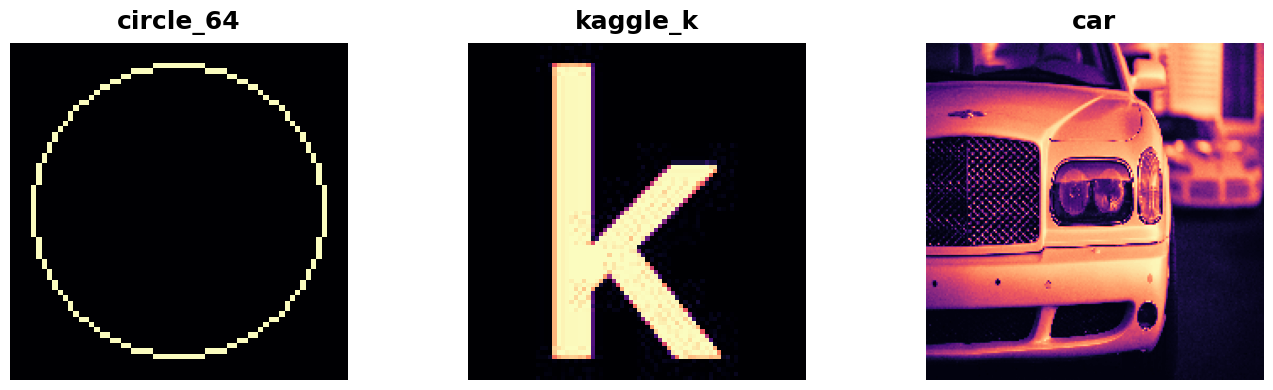

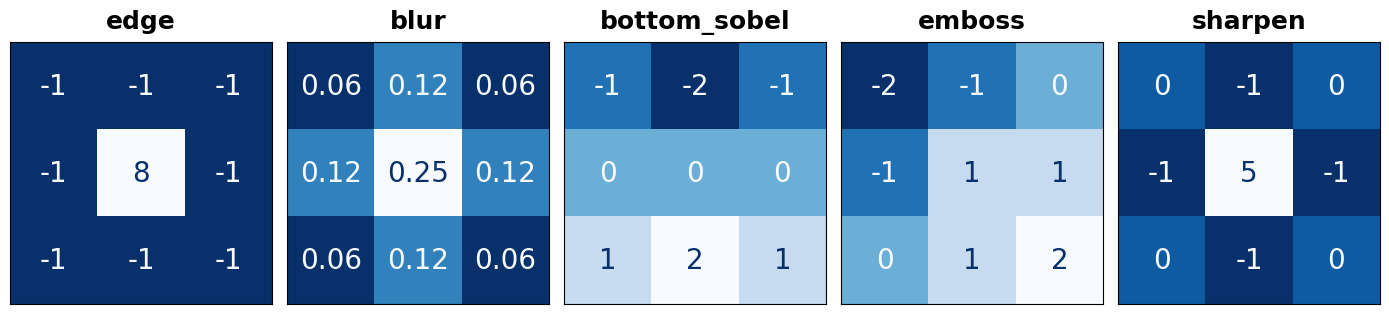

In [ ]:
from learntools.computer_vision.visiontools import edge, blur, bottom_sobel, emboss, sharpen, circle

image_dir = '../input/computer-vision-resources/'
circle_64 = tf.expand_dims(circle([64, 64], val=1.0, r_shrink=4), axis=-1)
kaggle_k = visiontools.read_image(image_dir + str('k.jpg'), channels=1)
car = visiontools.read_image(image_dir + str('car_illus.jpg'), channels=1)
car = tf.image.resize(car, size=[200, 200])
images = [(circle_64, "circle_64"), (kaggle_k, "kaggle_k"), (car, "car")]

plt.figure(figsize=(14, 4))
for i, (img, title) in enumerate(images):
    plt.subplot(1, len(images), i+1)
    plt.imshow(tf.squeeze(img))
    plt.axis('off')
    plt.title(title)
plt.show();

kernels = [(edge, "edge"), (blur, "blur"), (bottom_sobel, "bottom_sobel"),
           (emboss, "emboss"), (sharpen, "sharpen")]
plt.figure(figsize=(14, 4))
for i, (krn, title) in enumerate(kernels):
    plt.subplot(1, len(kernels), i+1)
    visiontools.show_kernel(krn, digits=2, text_size=20)
    plt.title(title)
plt.show()

To choose one to experiment with, just enter it's name in the appropriate place below. Then, set the parameters for the window computation. Try out some different combinations and see what they do!

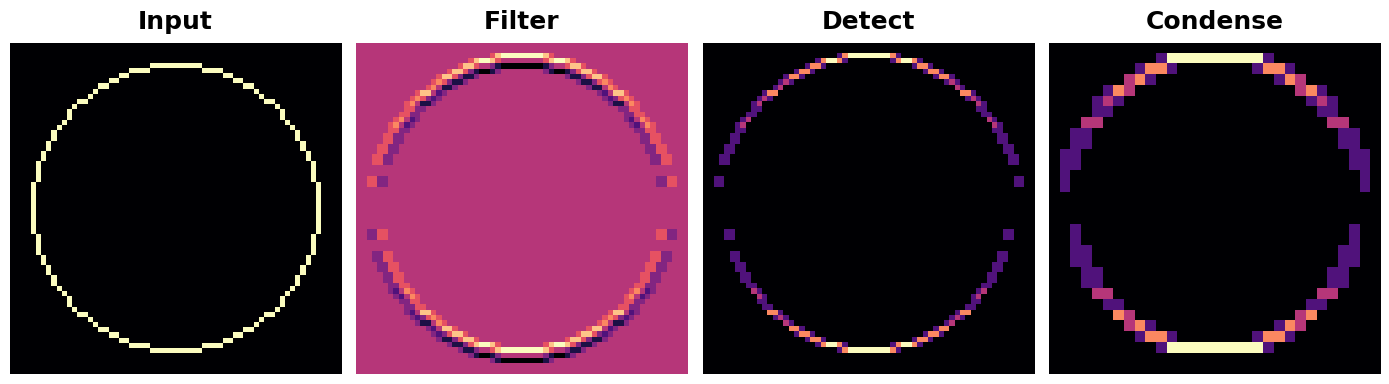

In [ ]:
# YOUR CODE HERE: choose an image
image = circle_64

# YOUR CODE HERE: choose a kernel
kernel = bottom_sobel

visiontools.show_extraction(
    image, kernel,

    # YOUR CODE HERE: set parameters
    conv_stride=1,
    conv_padding='valid',
    pool_size=2,
    pool_stride=2,
    pool_padding='same',

    subplot_shape=(1, 4),
    figsize=(14, 6),
)

## The Receptive Field #

Trace back all the connections from some neuron and eventually you reach the input image. All of the input pixels a neuron is connected to is that neuron's **receptive field**. The receptive field just tells you which parts of the input image a neuron receives information from.

As we've seen, if your first layer is a convolution with $3 \times 3$ kernels, then each neuron in that layer gets input from a $3 \times 3$ patch of pixels (except maybe at the border).

What happens if you add another convolutional layer with $3 \times 3$ kernels? Consider this next illustration:

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/HmwQm2S.png" alt="Illustration of the receptive field of two stacked convolutions." width=250>
</figure>

Now trace back the connections from the neuron at top and you can see that it's connected to a $5 \times 5$ patch of pixels in the input (the bottom layer): each neuron in the $3 \times 3$ patch in the middle layer is connected to a $3 \times 3$ input patch, but they overlap in a $5 \times 5$ patch. So that neuron at top has a $5 \times 5$ receptive field.

## 1) Growing the Receptive Field #

Now, if you added a *third* convolutional layer with a `(3, 3)` kernel, what receptive field would its neurons have? Run the cell below for an answer. (Or see a hint first!)

In [ ]:
# View the solution (Run this code cell to receive credit!)
q_1.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

The third layer would have a $7 \times 7$ receptive field.

In [ ]:
# Lines below will give you a hint
#q_1.hint()

So why stack layers like this? Three `(3, 3)` kernels have 27 parameters, while one `(7, 7)` kernel has 49, though they both create the same receptive field. This stacking-layers trick is one of the ways convnets are able to create large receptive fields without increasing the number of parameters too much. You'll see how to do this yourself in the next lesson!

## (Optional) One-Dimensional Convolution #

Convolutional networks turn out to be useful not only (two-dimensional) images, but also on things like time-series (one-dimensional) and video (three-dimensional).

We've seen how convolutional networks can learn to extract features from (two-dimensional) images. It turns out that convnets can also learn to extract features from things like time-series (one-dimensional) and video (three-dimensional).

In this (optional) exercise, we'll see what convolution looks like on a time-series.

The time series we'll use is from [Google Trends](https://trends.google.com/trends/). It measures the popularity of the search term "machine learning" for weeks from January 25, 2015 to January 15, 2020.

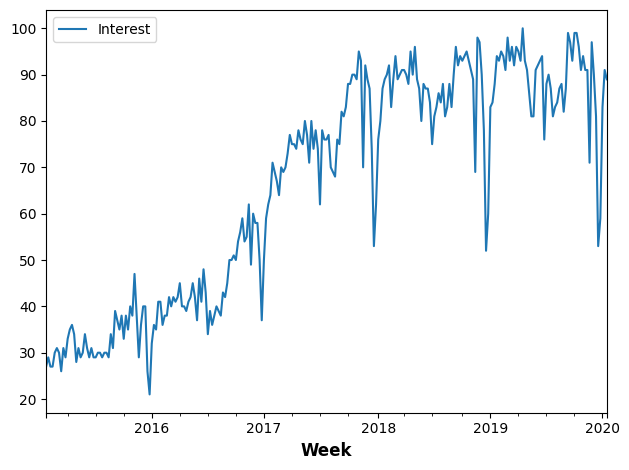

In [ ]:
import pandas as pd

# Load the time series as a Pandas dataframe
machinelearning = pd.read_csv(
    '../input/computer-vision-resources/machinelearning.csv',
    parse_dates=['Week'],
    index_col='Week',
)

machinelearning.plot();

What about the kernels? Images are two-dimensional and so our kernels were 2D arrays. A time-series is one-dimensional, so what should the kernel be? A 1D array! Here are some kernels sometimes used on time-series data:

In [ ]:
detrend = tf.constant([-1, 1], dtype=tf.float32)

average = tf.constant([0.2, 0.2, 0.2, 0.2, 0.2], dtype=tf.float32)

spencer = tf.constant([-3, -6, -5, 3, 21, 46, 67, 74, 67, 46, 32, 3, -5, -6, -3], dtype=tf.float32) / 320

Convolution on a sequence works just like convolution on an image. The difference is just that a sliding window on a sequence only has one direction to travel -- left to right -- instead of the two directions on an image. And just like before, the features picked out depend on the pattern on numbers in the kernel.

Can you guess what kind of features these kernels extract? Uncomment one of the kernels below and run the cell to see!

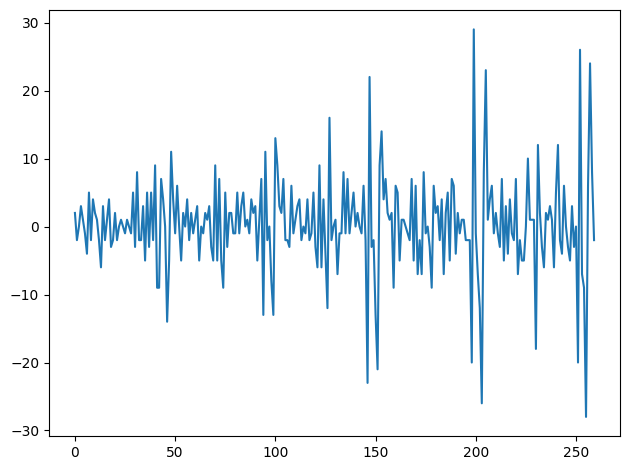

In [ ]:
# UNCOMMENT ONE
kernel = detrend
# kernel = average
# kernel = spencer

# Reformat for TensorFlow
ts_data = machinelearning.to_numpy()
ts_data = tf.expand_dims(ts_data, axis=0)
ts_data = tf.cast(ts_data, dtype=tf.float32)
kern = tf.reshape(kernel, shape=(*kernel.shape, 1, 1))

ts_filter = tf.nn.conv1d(
    input=ts_data,
    filters=kern,
    stride=1,
    padding='VALID',
)

# Format as Pandas Series
machinelearning_filtered = pd.Series(tf.squeeze(ts_filter).numpy())

machinelearning_filtered.plot();

In fact, the `detrend` kernel filters for *changes* in the series, while `average` and `spencer` are both "smoothers" that filter for low-frequency components in the series.

If you were interested in predicting the future popularity of search terms, you might train a convnet on time-series like this one. It would try to learn what features in those series are most informative for the prediction.

Though convnets are not often the best choice on their own for these kinds of problems, they are often incorporated into other models for their feature extraction capabilities.

## Conclusion #

This lesson ends our discussion of feature extraction. Hopefully, having completed these lessons, you've gained some intuition about how the process works and why the usual choices for its implementation are often the best ones.

# 5 Custom Convnets
Design your own convnet.



In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ryanholbrook_cv_course_models_path = kagglehub.dataset_download('ryanholbrook/cv-course-models')
ryanholbrook_computer_vision_resources_path = kagglehub.dataset_download('ryanholbrook/computer-vision-resources')
ryanholbrook_car_or_truck_path = kagglehub.dataset_download('ryanholbrook/car-or-truck')

print('Data source import complete.')


<!--TITLE:Custom Convnets-->
## Introduction #

Now that you've seen the layers a convnet uses to extract features, it's time to put them together and build a network of your own!

# Simple to Refined #

In the last three lessons, we saw how convolutional networks perform **feature extraction** through three operations: **filter**, **detect**, and **condense**. A single round of feature extraction can only extract relatively simple features from an image, things like simple lines or contrasts. These are too simple to solve most classification problems. Instead, convnets will repeat this extraction over and over, so that the features become more complex and refined as they travel deeper into the network.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/VqmC1rm.png" alt="Features extracted from an image of a car, from simple to refined." width=800>
</figure>

# Convolutional Blocks #

It does this by passing them through long chains of **convolutional blocks** which perform this extraction.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/pr8VwCZ.png" width="400" alt="Extraction as a sequence of blocks.">
</figure>

These convolutional blocks are stacks of `Conv2D` and `MaxPool2D` layers, whose role in feature extraction we learned about in the last few lessons.

<figure>
<!-- <img src="./images/2-block-crp.png" width="400" alt="A kind of extraction block: convolution, ReLU, pooling."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/8D6IhEw.png" width="400" alt="A kind of extraction block: convolution, ReLU, pooling.">
</figure>

Each block represents a round of extraction, and by composing these blocks the convnet can combine and recombine the features produced, growing them and shaping them to better fit the problem at hand. The deep structure of modern convnets is what allows this sophisticated feature engineering and has been largely responsible for their superior performance.

# Example - Design a Convnet #

Let's see how to define a deep convolutional network capable of engineering complex features. In this example, we'll create a Keras `Sequence` model and then train it on our Cars dataset.

## Step 1 - Load Data ##

This hidden cell loads the data.

In [ ]:

# Imports
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Reproducability
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed()

# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells


# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    '../input/car-or-truck/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
)
ds_valid_ = image_dataset_from_directory(
    '../input/car-or-truck/valid',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


### Step 2 - Define Model ##

Here is a diagram of the model we'll use:

<figure>
<!-- <img src="./images/2-convmodel-1.png" width="200" alt="Diagram of a convolutional model."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/U1VdoDJ.png" width="250" alt="Diagram of a convolutional model.">
</figure>

Now we'll define the model. See how our model consists of three blocks of `Conv2D` and `MaxPool2D` layers (the base) followed by a head of `Dense` layers. We can translate this diagram more or less directly into a Keras `Sequential` model just by filling in the appropriate parameters.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([

    # First Convolutional Block
    layers.Conv2D(filters=32, kernel_size=5, activation="relu", padding='same',
                  # give the input dimensions in the first layer
                  # [height, width, color channels(RGB)]
                  input_shape=[128, 128, 3]),
    layers.MaxPool2D(),

    # Second Convolutional Block
    layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding='same'),
    layers.MaxPool2D(),

    # Third Convolutional Block
    layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding='same'),
    layers.MaxPool2D(),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(units=6, activation="relu"),
    layers.Dense(units=1, activation="sigmoid"),
])
model.summary()

Notice in this definition is how the number of filters doubled block-by-block: 32, 64, 128. This is a common pattern. Since the `MaxPool2D` layer is reducing the *size* of the feature maps, we can afford to increase the *quantity* we create.

### Step 3 - Train ##

We can train this model just like the model from Lesson 1: compile it with an optimizer along with a loss and metric appropriate for binary classification.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(epsilon=0.01),
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=40,
    verbose=0,
)


In [ ]:
import pandas as pd

history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

This model is much smaller than the VGG16 model from Lesson 1 -- only 3 convolutional layers versus the 16 of VGG16. It was nevertheless able to fit this dataset fairly well. We might still be able to improve this simple model by adding more convolutional layers, hoping to create features better adapted to the dataset. This is what we'll try in the exercises.

## Conclusion #

In this tutorial, you saw how to build a custom convnet composed of many **convolutional blocks** and capable of complex feature engineering.


# 5 Ex Custom Convnets
Design your own convnet.



In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ryanholbrook_cv_course_models_path = kagglehub.dataset_download('ryanholbrook/cv-course-models')
ryanholbrook_computer_vision_resources_path = kagglehub.dataset_download('ryanholbrook/computer-vision-resources')
ryanholbrook_car_or_truck_path = kagglehub.dataset_download('ryanholbrook/car-or-truck')

print('Data source import complete.')


**This notebook is an exercise in the [Computer Vision](https://www.kaggle.com/learn/computer-vision) course.  You can reference the tutorial at [this link](https://www.kaggle.com/ryanholbrook/custom-convnets).**

---


## Introduction #

In these exercises, you'll build a custom convnet with performance competitive to the VGG16 model from Lesson 1.

Get started by running the code cell below.

In [ ]:
# Setup feedback system
from learntools.core import binder
binder.bind(globals())
from learntools.computer_vision.ex5 import *

# Imports
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Reproducability
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed()

# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells


# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    '../input/car-or-truck/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
)
ds_valid_ = image_dataset_from_directory(
    '../input/car-or-truck/valid',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


2026-07-21 21:37:23.070351: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-21 21:37:23.070451: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-21 21:37:23.203346: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 5117 files belonging to 2 classes.
Found 5051 files belonging to 2 classes.


## Design a Convnet #

Let's design a convolutional network with a block architecture like we saw in the tutorial. The model from the example had three blocks, each with a single convolutional layer. Its performance on the "Car or Truck" problem was okay, but far from what the pretrained VGG16 could achieve. It might be that our simple network lacks the ability to extract sufficiently complex features. We could try improving the model either by adding more blocks or by adding convolutions to the blocks we have.

Let's go with the second approach. We'll keep the three block structure, but increase the number of `Conv2D` layer in the second block to two, and in the third block to three.

<figure>
<!-- <img src="./images/2-convmodel-2.png" width="250" alt="Diagram of a convolutional model."> -->
<img src="https://storage.googleapis.com/kaggle-media/learn/images/Vko6nCK.png" width="250" alt="Diagram of a convolutional model.">
</figure>

# 1) Define Model #

Given the diagram above, complete the model by defining the layers of the third block.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    # Block One
    layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same',
                  input_shape=[128, 128, 3]),
    layers.MaxPool2D(),

    # Block Two
    layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPool2D(),

    # Block Three
    layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding='same'),
    layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding='same'),
    layers.MaxPool2D(),

    # Head
    layers.Flatten(),
    layers.Dense(6, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid'),
])

# Check your answer
q_1.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#q_1.hint()
#q_1.solution()

## 2) Compile #

To prepare for training, compile the model with an appropriate loss and accuracy metric for the "Car or Truck" dataset.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(epsilon=0.01),
     loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

# Check your answer
q_2.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(epsilon=0.01),
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)
q_2.assert_check_passed()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#q_2.hint()
#q_2.solution()

Finally, let's test the performance of this new model. First run this cell to fit the model to the training set.

In [ ]:
history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=50,
)

Epoch 1/50


I0000 00:00:1784669921.196246     106 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


80/80 [==============================] - 17s 146ms/step - loss: 0.6838 - binary_accuracy: 0.5658 - val_loss: 0.6730 - val_binary_accuracy: 0.5783
Epoch 2/50
80/80 [==============================] - 3s 41ms/step - loss: 0.6699 - binary_accuracy: 0.5873 - val_loss: 0.6585 - val_binary_accuracy: 0.6171
Epoch 3/50
80/80 [==============================] - 3s 41ms/step - loss: 0.6603 - binary_accuracy: 0.6007 - val_loss: 0.6513 - val_binary_accuracy: 0.6252
Epoch 4/50
80/80 [==============================] - 3s 41ms/step - loss: 0.6564 - binary_accuracy: 0.6103 - val_loss: 0.6455 - val_binary_accuracy: 0.6369
Epoch 5/50
80/80 [==============================] - 3s 41ms/step - loss: 0.6456 - binary_accuracy: 0.6220 - val_loss: 0.6367 - val_binary_accuracy: 0.6387
Epoch 6/50
80/80 [==============================] - 3s 41ms/step - loss: 0.6409 - binary_accuracy: 0.6261 - val_loss: 0.6290 - val_binary_accuracy: 0.6488
Epoch 7/50
80/80 [==============================] - 3s 41ms/step - loss: 0.6342

And now run the cell below to plot the loss and metric curves for this training run.

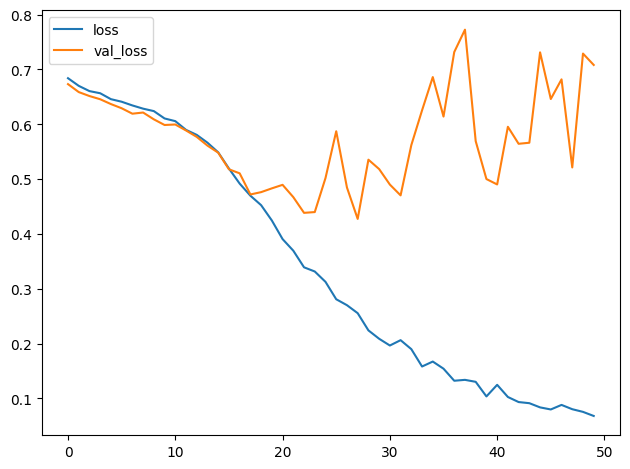

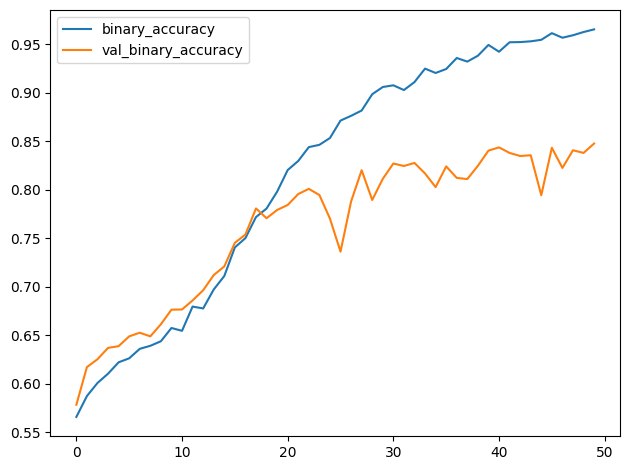

In [ ]:
import pandas as pd
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

## 3) Train the Model #

How would you interpret these training curves? Did this model improve upon the model from the tutorial?

In [ ]:
# View the solution (Run this code cell to receive credit!)
q_3.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 


The learning curves for the model from the tutorial diverged fairly rapidly. This would indicate that it was prone to overfitting and in need of some regularization. The additional layer in our new model would make it even more prone to overfitting. However, adding some regularization with the `Dropout` layer helped prevent this. These changes improved the validation accuracy of the model by several points.



The learning curves for the model from the tutorial diverged fairly rapidly. This would indicate that it was prone to overfitting and in need of some regularization. The additional layer in our new model would make it even more prone to overfitting. However, adding some regularization with the Dropout layer helped prevent this. These changes improved the validation accuracy of the model by several points.

## Conclusion #

These exercises showed you how to design a custom convolutional network to solve a specific classification problem. Though most models these days will be built on top of a pretrained base, it certain circumstances a smaller custom convnet might still be preferable -- such as with a smaller or unusual dataset or when computing resources are very limited. As you saw here, for certain problems they can perform just as well as a pretrained model.


# 6 Data Augmentation
Boost performance by creating extra training data.

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ryanholbrook_eurosat_path = kagglehub.dataset_download('ryanholbrook/eurosat')
ryanholbrook_cv_course_models_path = kagglehub.dataset_download('ryanholbrook/cv-course-models')
ryanholbrook_computer_vision_resources_path = kagglehub.dataset_download('ryanholbrook/computer-vision-resources')
ryanholbrook_car_or_truck_path = kagglehub.dataset_download('ryanholbrook/car-or-truck')
ryanholbrook_tensorflow_flowers_path = kagglehub.dataset_download('ryanholbrook/tensorflow-flowers')

print('Data source import complete.')


<!--TITLE:Data Augmentation-->

## Introduction #

Now that you've learned the fundamentals of convolutional classifiers, you're ready to move on to more advanced topics.

In this lesson, you'll learn a trick that can give a boost to your image classifiers: it's called **data augmentation**.

## The Usefulness of Fake Data #

The best way to improve the performance of a machine learning model is to train it on more data. The more examples the model has to learn from, the better it will be able to recognize which differences in images matter and which do not. More data helps the model to *generalize* better.

One easy way of getting more data is to use the data you already have. If we can transform the images in our dataset in ways that preserve the class, we can teach our classifier to ignore those kinds of transformations. For instance, whether a car is facing left or right in a photo doesn't change the fact that it is a *Car* and not a *Truck*. So, if we **augment** our training data with flipped images, our classifier will learn that "left or right" is a difference it should ignore.

And that's the whole idea behind data augmentation: add in some extra fake data that looks reasonably like the real data and your classifier will improve.

## Using Data Augmentation #

Typically, many kinds of transformation are used when augmenting a dataset. These might include rotating the image, adjusting the color or contrast, warping the image, or many other things, usually applied in combination. Here is a sample of the different ways a single image might be transformed.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/UaOm0ms.png" width=400, alt="Sixteen transformations of a single image of a car.">
</figure>

Data augmentation is usually done *online*, meaning, as the images are being fed into the network for training. Recall that training is usually done on mini-batches of data. This is what a batch of 16 images might look like when data augmentation is used.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/MFviYoE.png" width=400, alt="A batch of 16 images with various random transformations applied.">
</figure>

Each time an image is used during training, a new random transformation is applied. This way, the model is always seeing something a little different than what it's seen before. This extra variance in the training data is what helps the model on new data.

It's important to remember though that not every transformation will be useful on a given problem. Most importantly, whatever transformations you use should not mix up the classes. If you were training a [digit recognizer](https://www.kaggle.com/c/digit-recognizer), for instance, rotating images would mix up '9's and '6's. In the end, the best approach for finding good augmentations is the same as with most ML problems: try it and see!

## Example - Training with Data Augmentation #

Keras lets you augment your data in two ways. The first way is to include it in the data pipeline with a function like [`ImageDataGenerator`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator). The second way is to include it in the model definition by using Keras's **preprocessing layers**. This is the approach that we'll take. The primary advantage for us is that the image transformations will be computed on the GPU instead of the CPU, potentially speeding up training.

In this exercise, we'll learn how to improve the classifier from Lesson 1 through data augmentation. This next hidden cell sets up the data pipeline.

In [ ]:

# Imports
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Reproducability
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    #os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed()

# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells


# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    '../input/car-or-truck/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
)
ds_valid_ = image_dataset_from_directory(
    '../input/car-or-truck/valid',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


### Step 2 - Define Model ##

To illustrate the effect of augmentation, we'll just add a couple of simple transformations to the model from Tutorial 1.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
# these are a new feature in TF 2.2
from tensorflow.keras.layers.experimental import preprocessing


pretrained_base = tf.keras.models.load_model(
    '../input/cv-course-models/cv-course-models/vgg16-pretrained-base',
)
pretrained_base.trainable = False

model = keras.Sequential([
    # Preprocessing
    preprocessing.RandomFlip('horizontal'), # flip left-to-right
    preprocessing.RandomContrast(0.5), # contrast change by up to 50%
    # Base
    pretrained_base,
    # Head
    layers.Flatten(),
    layers.Dense(6, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

### Step 3 - Train and Evaluate ##

And now we'll start the training!

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=30,
    verbose=0,
)

In [ ]:
import pandas as pd

history_frame = pd.DataFrame(history.history)

history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

The training and validation curves in the model from Tutorial 1 diverged fairly quickly, suggesting that it could benefit from some regularization. The learning curves for this model were able to stay closer together, and we achieved some modest improvement in validation loss and accuracy. This suggests that the dataset did indeed benefit from the augmentation.


# 6 Ex Data Augmentation
Boost performance by creating extra training data.

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ryanholbrook_eurosat_path = kagglehub.dataset_download('ryanholbrook/eurosat')
ryanholbrook_cv_course_models_path = kagglehub.dataset_download('ryanholbrook/cv-course-models')
ryanholbrook_computer_vision_resources_path = kagglehub.dataset_download('ryanholbrook/computer-vision-resources')
ryanholbrook_car_or_truck_path = kagglehub.dataset_download('ryanholbrook/car-or-truck')
ryanholbrook_tensorflow_flowers_path = kagglehub.dataset_download('ryanholbrook/tensorflow-flowers')

print('Data source import complete.')


**This notebook is an exercise in the [Computer Vision](https://www.kaggle.com/learn/computer-vision) course.  You can reference the tutorial at [this link](https://www.kaggle.com/ryanholbrook/data-augmentation).**

---


## Introduction #

In these exercises, you'll explore what effect various random transformations have on an image, consider what kind of augmentation might be appropriate on a given dataset, and then use data augmentation with the *Car or Truck* dataset to train a custom network.

Run the cell below to set everything up!

In [ ]:
# Setup feedback system
from learntools.core import binder
binder.bind(globals())
from learntools.computer_vision.ex6 import *

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing

# Imports
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Reproducability
def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    #os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_seed()

# Set Matplotlib defaults
plt.rc('figure', autolayout=True)
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings("ignore") # to clean up output cells


# Load training and validation sets
ds_train_ = image_dataset_from_directory(
    '../input/car-or-truck/train',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=True,
)
ds_valid_ = image_dataset_from_directory(
    '../input/car-or-truck/valid',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,
)

# Data Pipeline
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)


2026-07-21 21:45:18.170167: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-21 21:45:18.170287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-21 21:45:18.284020: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 5117 files belonging to 2 classes.
Found 5051 files belonging to 2 classes.


## (Optional) Explore Augmentation #

Uncomment a transformation and run the cell to see what it does. You can experiment with the parameter values too, if you like. (The `factor` parameters should be greater than 0 and, generally, less than 1.) Run the cell again if you'd like to get a new random image.

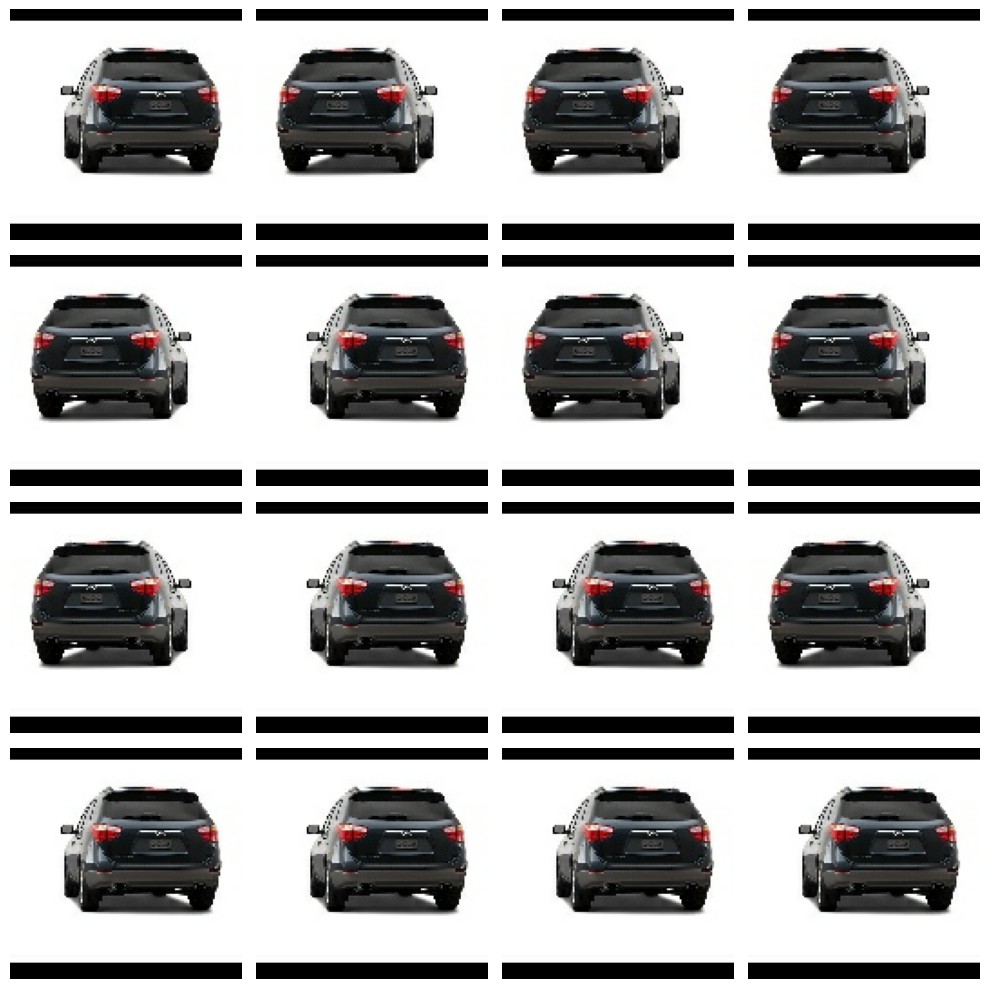

In [ ]:
# all of the "factor" parameters indicate a percent-change
augment = keras.Sequential([
    # preprocessing.RandomContrast(factor=0.5),
    preprocessing.RandomFlip(mode='horizontal'), # meaning, left-to-right
    # preprocessing.RandomFlip(mode='vertical'), # meaning, top-to-bottom
    # preprocessing.RandomWidth(factor=0.15), # horizontal stretch
    # preprocessing.RandomRotation(factor=0.20),
    # preprocessing.RandomTranslation(height_factor=0.1, width_factor=0.1),
])


ex = next(iter(ds_train.unbatch().map(lambda x, y: x).batch(1)))

plt.figure(figsize=(10,10))
for i in range(16):
    image = augment(ex, training=True)
    plt.subplot(4, 4, i+1)
    plt.imshow(tf.squeeze(image))
    plt.axis('off')
plt.show()

Do the transformations you chose seem reasonable for the *Car or Truck* dataset?

In this exercise, we'll look at a few datasets and think about what kind of augmentation might be appropriate. Your reasoning might be different that what we discuss in the solution. That's okay. The point of these problems is just to think about how a transformation might interact with a classification problem -- for better or worse.

The [EuroSAT](https://www.kaggle.com/ryanholbrook/eurosat) dataset consists of satellite images of the Earth classified by geographic feature. Below are a number of images from this dataset.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/LxARYZe.png" width=600, alt="Sixteen satellite images labeled: SeaLake, PermanentCrop, Industrial, Pasture, Residential, and Forest.">
</figure>

## 1) EuroSAT #

What kinds of transformations might be appropriate for this dataset?

In [ ]:
# View the solution (Run this code cell to receive credit!)
q_1.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

It seems to this author that flips and rotations would be worth trying first since there's no concept of orientation for pictures taken straight overhead. None of the transformations seem likely to confuse classes, however.


It seems to this author that flips and rotations would be worth trying first since there's no concept of orientation for pictures taken straight overhead. None of the transformations seem likely to confuse classes, however.

In [ ]:
# Lines below will give you a hint
# q_1.solution()

The [TensorFlow Flowers](https://www.kaggle.com/ryanholbrook/tensorflow-flowers) dataset consists of photographs of flowers of several species. Below is a sample.

<figure>
<img src="https://storage.googleapis.com/kaggle-media/learn/images/Mt7PR2x.png" width=600, alt="Sixteen images of flowers labeled: roses, tulips, dandelion, and sunflowers">
</figure>

## 2) TensorFlow Flowers #

What kinds of transformations might be appropriate for the TensorFlow Flowers dataset?

In [ ]:
# View the solution (Run this code cell to receive credit!)
q_2.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

It seems to this author that horizontal flips and moderate rotations would be worth trying first. Some augmentation libraries include transformations of hue (like red to blue). Since the color of a flower seems distinctive of its class, a change of hue might be less successful. On the other hand, there is suprising variety in cultivated flowers like roses, so, depending on the dataset, this might be an improvement after all!



It seems to this author that horizontal flips and moderate rotations would be worth trying first. Some augmentation libraries include transformations of hue (like red to blue). Since the color of a flower seems distinctive of its class, a change of hue might be less successful. On the other hand, there is suprising variety in cultivated flowers like roses, so, depending on the dataset, this might be an improvement after all!

In [ ]:
# Lines below will give you a hint
#q_2.solution()

Now you'll use data augmentation with a custom convnet similar to the one you built in Exercise 5. Since data augmentation effectively increases the size of the dataset, we can increase the capacity of the model in turn without as much risk of overfitting.

## 3) Add Preprocessing Layers #

Add these preprocessing layers to the given model.

```
preprocessing.RandomContrast(factor=0.10),
preprocessing.RandomFlip(mode='horizontal'),
preprocessing.RandomRotation(factor=0.10),
```


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.InputLayer(input_shape=[128, 128, 3]),

    # Data Augmentation
    preprocessing.RandomContrast(factor=0.10),
    preprocessing.RandomFlip(mode='horizontal'),
    preprocessing.RandomRotation(factor=0.10),

    # Block One
    layers.BatchNormalization(renorm=True),
    layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPool2D(),

    # Block Two
    layers.BatchNormalization(renorm=True),
    layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPool2D(),

    # Block Three
    layers.BatchNormalization(renorm=True),
    layers.Conv2D(filters=256, kernel_size=3, activation='relu', padding='same'),
    layers.Conv2D(filters=256, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPool2D(),

    # Head
    layers.BatchNormalization(renorm=True),
    layers.Flatten(),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

# Check your answer
q_3.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#q_3.hint()
#q_3.solution()

Now we'll train the model. Run the next cell to compile it with a loss and accuracy metric and fit it to the training set.

Epoch 1/50


I0000 00:00:1784670488.024433     106 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


80/80 [==============================] - 25s 186ms/step - loss: 0.6701 - binary_accuracy: 0.5957 - val_loss: 0.6388 - val_binary_accuracy: 0.6268
Epoch 2/50
80/80 [==============================] - 7s 87ms/step - loss: 0.6629 - binary_accuracy: 0.6097 - val_loss: 0.6743 - val_binary_accuracy: 0.6149
Epoch 3/50
80/80 [==============================] - 7s 87ms/step - loss: 0.6238 - binary_accuracy: 0.6447 - val_loss: 0.5898 - val_binary_accuracy: 0.6820
Epoch 4/50
80/80 [==============================] - 7s 88ms/step - loss: 0.5860 - binary_accuracy: 0.6983 - val_loss: 0.5847 - val_binary_accuracy: 0.6884
Epoch 5/50
80/80 [==============================] - 7s 88ms/step - loss: 0.5587 - binary_accuracy: 0.7149 - val_loss: 0.6103 - val_binary_accuracy: 0.6872
Epoch 6/50
80/80 [==============================] - 7s 87ms/step - loss: 0.5067 - binary_accuracy: 0.7610 - val_loss: 0.6199 - val_binary_accuracy: 0.6989
Epoch 7/50
80/80 [==============================] - 7s 87ms/step - loss: 0.4616

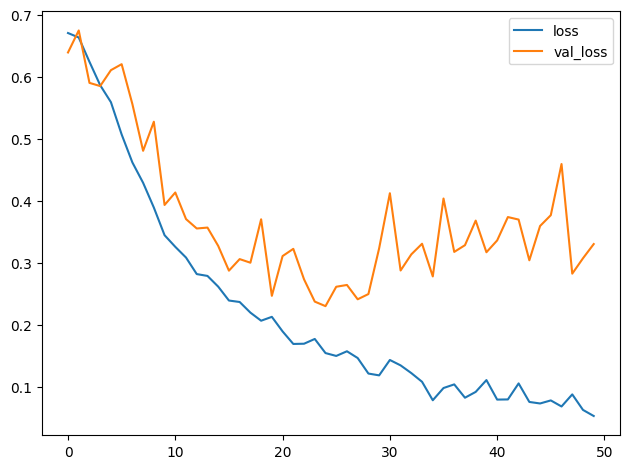

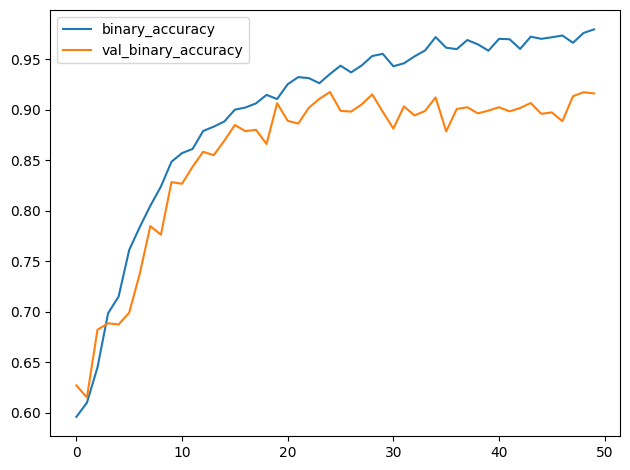

In [ ]:
optimizer = tf.keras.optimizers.Adam(epsilon=0.01)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=50,
)

# Plot learning curves
import pandas as pd
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

## 4) Train Model #

Examine the training curves. What there any sign of overfitting? How does the performance of this model compare to other models you've trained in this course?

In [ ]:
# View the solution (Run this code cell to receive credit!)
q_4.solution()

<IPython.core.display.Javascript object>

<span style="color:#33cc99">Solution:</span> 
The learning curves in this model stayed close together for much longer than in previous models. This suggests that the augmentation helped prevent overfitting, allowing the model to continue improving.

And notice that this model achieved the highest accuracy of all the models in the course! This won't always be the case, but it shows that a well-designed custom convnet can sometimes perform as well or better than a much larger pretrained model. Depending on your application, having a smaller model (which requires fewer resources) could be a big advantage.


## Conclusion #

Data augmentation is a powerful and commonly-used tool to improve model training, not only for convolutional networks, but for many other kinds of neural network models as well. Whatever your problem, the principle remains the same: you can make up for an inadequacy in your data by adding in "fake" data to cover it over. Experimenting with augmentations is a great way to find out just how far your data can go!